## Technical Analysis and Machine Learning for Swing-Trade Entry Timing: A Data Science Study of Oracle Corporation (ORCL), 1986–2026

- **Module:** 7CS078/UZ1: Data Science
- **Author:** Santiago Cruz | **ID:** 2584023
- **Dataset:** NYSE: Oracle (`ORCL`), Daily Bars, 1986–2026
- **Dataset Source:** TradingView
- **Date:** August 24, 2026
- **The University of Wolverhampton**

**Abstract:** A data science pipeline combining technical indicators (RSI, TSI, SMAs, ATR) with statistical and ML models (Logistic Regression, Neural Network, Random Forest, PCA, K-Means, HMM, LSTM) to classify 21-day Buy/Hold/Sell signals, forecast price ranges, and produce risk-bounded entry/exit levels for ORCL. Full abstract, literature review, and discussion are in the accompanying written report - this notebook holds the code and short section labels only.

### Table of Contents
1. Problem Statement
2. Related Work
3. Dataset
4. Environment & Library Setup
5. Data Loading & Cleaning
6. Exploratory Data Analysis
7. Feature Engineering
8. Algorithm Selection
9. Training & Evaluation
10. Actionable Entry & Exit Levels
11. Conclusion
12. References

### 1. Problem Statement

Predict 21-day Buy/Hold/Sell direction and price range for ORCL, and convert model output into concrete entry/exit levels with a defined Stop-Loss/Take-Profit. Full motivation and research questions are in the written report, Section 1.

### 2. Related Work

Grounds the indicators (Murphy, 1999; Wilder, 1978; Blau, 1991) and models (Fischer & Krauss, 2018; Nti et al., 2020) used below, and the EMH null hypothesis (Fama, 1970; Malkiel, 2003). Full discussion in the written report, Section 2.

### 3. Dataset

ORCL daily OHLC bars, TradingView (BATS/NYSE), 1986-2026, 10,185 rows x 18 columns; includes SMAs, RSI, TSI, and moon-phase flags. Full source, field, and preprocessing discussion in the written report, Section 3.

### 4. Environment & Library Setup

Imports and confirms every library used below (pandas/numpy, matplotlib/seaborn/plotly, scikit-learn/statsmodels, TensorFlow/Keras, hmmlearn).

In [3]:
import sys
import warnings

# Suppress minor deprecation warnings (like the TensorFlow internal keras one)
warnings.filterwarnings('ignore')

print("--- SYSTEM CONFIGURATION ---")
print("OS Platform:      ", sys.platform)
print("Python version:   ", sys.version.split('\n')[0])
print("Conda Environment:", sys.prefix)
print("-" * 30)

from pathlib import Path
import requests

# Core Data Science Frameworks
import sys
print(sys.executable)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import plotly
import seaborn as sns

print("--- CORE FRAMEWORKS ---")
print("NumPy version:     ", np.__version__)
print("Pandas version:    ", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:   ", sns.__version__)
print("-" * 30)

# Deep Learning Frameworks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("--- DEEP LEARNING ---")
print("TensorFlow version:", tf.__version__)

# GPU robustness: some environments intermittently report the GPU as "busy or
# unavailable" (cudaSetDevice() InternalError), usually because another process
# or kernel is already holding it. Rather than let every model-building cell in
# Sections 9.3, 9.8 and 9.8b hit that wall independently, run a tiny real op on
# the GPU here, once, and fall back to CPU for the rest of the session if it fails.
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    try:
        for gpu in gpu_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        with tf.device('/GPU:0'):
            _ = tf.constant([1.0]) + tf.constant([1.0])
        print(f"GPU detected and usable: {[g.name for g in gpu_devices]}")
    except Exception as gpu_error:
        print(f"GPU present but not usable right now ({type(gpu_error).__name__}) - falling back to CPU for this session.")
        tf.config.set_visible_devices([], 'GPU')
else:
    print("No GPU detected - running on CPU.")
print("-" * 30)

# Statistical & Time Series Modeling
import statsmodels
from statsmodels.tsa.stattools import adfuller
from scipy import stats

# Machine Learning & Analytics Evaluation Tools
import sklearn
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    mean_absolute_error, mean_squared_error
)

print("--- MACHINE LEARNING & STATS ---")
print("Scikit-learn version:", sklearn.__version__)
print("Statsmodels version: ", statsmodels.__version__)
print("-" * 30)

# Hidden Markov Models Block (optional extension, not part of the 7-week syllabus)
try:
    import hmmlearn
    from hmmlearn.hmm import GaussianHMM
    print(f"hmmlearn version:    {hmmlearn.__version__}")
    HMMLEARN_AVAILABLE = True
except ImportError:
    HMMLEARN_AVAILABLE = False
    print("hmmlearn is not installed. HMM functionality will be unavailable.")
print("-" * 30)

print("\nAll targeted libraries imported successfully. System ready for development")

--- SYSTEM CONFIGURATION ---
OS Platform:       linux
Python version:    3.10.20 (main, Jun 11 2026, 15:17:37) [GCC 14.3.0]
Conda Environment: /home/dev-algo/anaconda3/envs/WLV-TF
------------------------------
/home/dev-algo/anaconda3/envs/WLV-TF/bin/python
--- CORE FRAMEWORKS ---
NumPy version:      1.26.4
Pandas version:     2.3.3
Matplotlib version: 3.10.8
Seaborn version:    0.13.2
------------------------------


2026-08-23 12:05:54.490927: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-23 12:05:54.491003: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-23 12:05:54.517483: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-23 12:05:54.575192: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-23 12:05:55.717713: W tensorflow/compiler/tf2

--- DEEP LEARNING ---
TensorFlow version: 2.15.1
GPU detected and usable: ['/physical_device:GPU:0']
------------------------------
--- MACHINE LEARNING & STATS ---
Scikit-learn version: 1.7.2
Statsmodels version:  0.14.6
------------------------------
hmmlearn version:    0.3.3
------------------------------

All targeted libraries imported successfully. System ready for development


2026-08-23 12:05:56.746376: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-23 12:05:56.879508: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-23 12:05:56.879697: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

### 5. Data Loading & Cleaning

Loads the CSV, coerces types, drops invalid/duplicate rows, and reports missing values (expected leading NaNs in the longer-window SMAs).

In [4]:
# Load the dataset
csv_path = Path("NYSE_BATS_ORCL_1D.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Dataset not found: {csv_path.resolve()}")

raw_df = pd.read_csv(csv_path, sep=";")
print("Raw shape:", raw_df.shape)
print("Raw columns:", list(raw_df.columns))

df = raw_df.copy()

# Defensive re-parse: some exports land as a single semicolon-delimited column that
# is actually comma-separated. Keep the required market-structure columns exactly.
if df.shape[1] == 1 and df.columns[0].startswith("time,"):
    df = df.iloc[:, 0].str.split(",", expand=True)
    df.columns = [
        "time", "open", "high", "low", "close",
        "SMA_756_Close", "SMA_VWMA_756", "SMA_504_Close", "SMA_VWMA_504",
        "SMA_252_Close", "SMA_125_Close", "SMA_63_Close", "SMA_21_Close",
        "TSI_25_13_13", "TSI_Signal_13", "RSI_25_Close",
        "RSI_SMA_14", "New_Moon", "Full_Moon"
    ]

# Keep only the expected fields in the exact order required downstream.
required_columns = [
    "time", "open", "high", "low", "close",
    "SMA_756_Close", "SMA_VWMA_756", "SMA_504_Close", "SMA_VWMA_504",
    "SMA_252_Close", "SMA_125_Close", "SMA_63_Close", "SMA_21_Close",
    "TSI_25_13_13", "TSI_Signal_13", "RSI_25_Close",
    "RSI_SMA_14", "New_Moon", "Full_Moon"
]
existing_columns = [col for col in required_columns if col in df.columns]
df = df[existing_columns].copy()

# Normalise timestamps and remove invalid/duplicate records.
df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")

invalid_ts = df["time"].isna().sum()
dup_count_before = df.duplicated().sum()

df = df.dropna(subset=["time"]).drop_duplicates().sort_values("time").set_index("time")

# OHLC and indicator values must be numeric before feature generation.
for col in ["open", "high", "low", "close", "SMA_756_Close", "SMA_VWMA_756",
            "SMA_504_Close", "SMA_VWMA_504", "SMA_252_Close", "SMA_125_Close",
            "SMA_63_Close", "SMA_21_Close", "TSI_25_13_13",
            "TSI_Signal_13", "RSI_25_Close", "RSI_SMA_14"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Preserve the moon phase flags as integers/bools if they are not already.
for col in ["New_Moon", "Full_Moon"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nInvalid timestamps removed:", invalid_ts)
print("Duplicate rows removed:", dup_count_before)
print("Final shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)

# Return a summary table for the cleaned dataset
summary_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isna().sum().values,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

summary_table


Raw shape: (10185, 1)
Raw columns: ['time,open,high,low,close,SMA_756_Close,SMA_VWMA_756,SMA_504_Close,SMA_VWMA_504,SMA_252_Close,SMA_125_Close,SMA_63_Close,SMA_21_Close,TSI_25_13_13,TSI_Signal_13,RSI_25_Close,RSI_SMA_14,New_Moon,Full_Moon']

Invalid timestamps removed: 0
Duplicate rows removed: 0
Final shape: (10185, 18)

Missing values per column:
 open               0
high               0
low                0
close              0
SMA_756_Close    755
SMA_VWMA_756     768
SMA_504_Close    503
SMA_VWMA_504     516
SMA_252_Close    251
SMA_125_Close    124
SMA_63_Close      62
SMA_21_Close      20
TSI_25_13_13      37
TSI_Signal_13     49
RSI_25_Close      25
RSI_SMA_14        38
New_Moon           0
Full_Moon          0
dtype: int64

Data types:
 open             float64
high             float64
low              float64
close            float64
SMA_756_Close    float64
SMA_VWMA_756     float64
SMA_504_Close    float64
SMA_VWMA_504     float64
SMA_252_Close    float64
SMA_125_Close    

,Column,Data Type,Missing Values,Unique Values
0,open,float64,0,5838
1,high,float64,0,5948
2,low,float64,0,6001
3,close,float64,0,5969
4,SMA_756_Close,float64,755,9406
5,SMA_VWMA_756,float64,768,9417
6,SMA_504_Close,float64,503,9670
7,SMA_VWMA_504,float64,516,9669
8,SMA_252_Close,float64,251,9918
9,SMA_125_Close,float64,124,9999


In [5]:
# Display the cleaned dataframe with actual values in table form

df.reset_index().tail(15)

,time,open,high,low,close,SMA_756_Close,SMA_VWMA_756,SMA_504_Close,SMA_VWMA_504,SMA_252_Close,SMA_125_Close,SMA_63_Close,SMA_21_Close,TSI_25_13_13,TSI_Signal_13,RSI_25_Close,RSI_SMA_14,New_Moon,Full_Moon
10170,2026-08-03 00:00:00+00:00,131.920,143.0700,130.2100,141.85,162.669087,162.598644,185.079206,185.267746,200.090079,162.21320,169.286984,129.499048,-26.161902,-35.432710,46.902185,37.012460,0,0
10171,2026-08-04 00:00:00+00:00,141.010,148.7000,141.0100,145.74,162.708439,162.612217,185.099187,185.232692,199.698492,162.14176,168.738571,129.593333,-20.122153,-33.245488,48.500938,37.869936,0,0
10172,2026-08-05 00:00:00+00:00,145.000,146.3899,142.5000,144.39,162.744365,162.623963,185.108988,185.201772,199.269365,162.12352,168.088413,129.726191,-15.597096,-30.724289,47.978703,38.848686,0,0
10173,2026-08-06 00:00:00+00:00,139.250,146.5800,138.7200,143.47,162.778175,162.635371,185.120813,185.179436,198.824127,162.17944,167.285873,129.868095,-12.139631,-28.069338,47.614754,39.723711,0,0
10174,2026-08-07 00:00:00+00:00,145.320,147.1600,142.3400,147.02,162.819590,162.648717,185.148075,185.162047,198.389960,162.21304,166.530794,130.001429,-8.407058,-25.260441,49.164735,40.805279,0,0
10175,2026-08-10 00:00:00+00:00,148.260,151.9900,146.6200,151.05,162.867870,162.663705,185.194087,185.152522,197.999722,162.16872,165.818095,130.497143,-4.350409,-22.273293,50.883247,41.808621,0,0
10176,2026-08-11 00:00:00+00:00,151.200,151.9900,144.2400,145.48,162.908929,162.681625,185.228353,185.149578,197.584762,162.05344,165.050476,131.160952,-2.348540,-19.426900,48.521670,42.667988,0,0
10177,2026-08-12 00:00:00+00:00,152.810,154.8900,147.8900,153.28,162.958109,162.711971,185.282679,185.152923,197.190317,162.02240,164.517936,132.367619,1.138778,-16.488946,51.785821,43.877253,0,0
10178,2026-08-13 00:00:00+00:00,151.980,159.2600,151.9100,156.22,163.012328,162.740584,185.336766,185.154577,196.802857,162.02032,163.985556,133.497619,4.590848,-13.477547,52.956997,45.267366,1,0
10179,2026-08-14 00:00:00+00:00,155.840,156.3900,148.8001,150.52,163.061825,162.768054,185.373393,185.161740,196.431191,161.94336,163.269841,134.750476,5.908904,-10.708054,50.480556,46.299921,0,0


### 6. Exploratory Data Analysis

Descriptive stats, outlier detection, trend charts, correlation, seasonality, support/resistance, and hypothesis tests (stationarity, RSI regime, moon phase).

#### 6.1 Descriptive Statistics

In [6]:
# Descriptive statistics (Week 1) for the core price and indicator columns
desc_cols = ['open', 'high', 'low', 'close', 'RSI_25_Close', 'TSI_25_13_13']
df[desc_cols].describe().round(3)

,open,high,low,close,RSI_25_Close,TSI_25_13_13
count,10185.000,10185.000,10185.000,10185.000,10160.000,10148.000
mean,33.669,34.113,33.206,33.657,52.605,5.359
std,45.350,45.999,44.569,45.269,8.610,19.431
min,0.042,0.044,0.040,0.042,24.496,-57.121
25%,3.620,3.685,3.528,3.604,46.590,-8.076
50%,18.690,18.980,18.370,18.730,52.934,6.023
75%,42.000,42.500,41.590,42.060,58.555,19.478
max,330.340,345.720,312.090,328.330,83.123,67.863


#### 6.2 Outlier Detection

Flags extreme daily moves via the IQR rule before modelling.

IQR outlier fence: [-0.0890, 0.0900]
Flagged 159 extreme daily moves out of 10184 (1.56%)


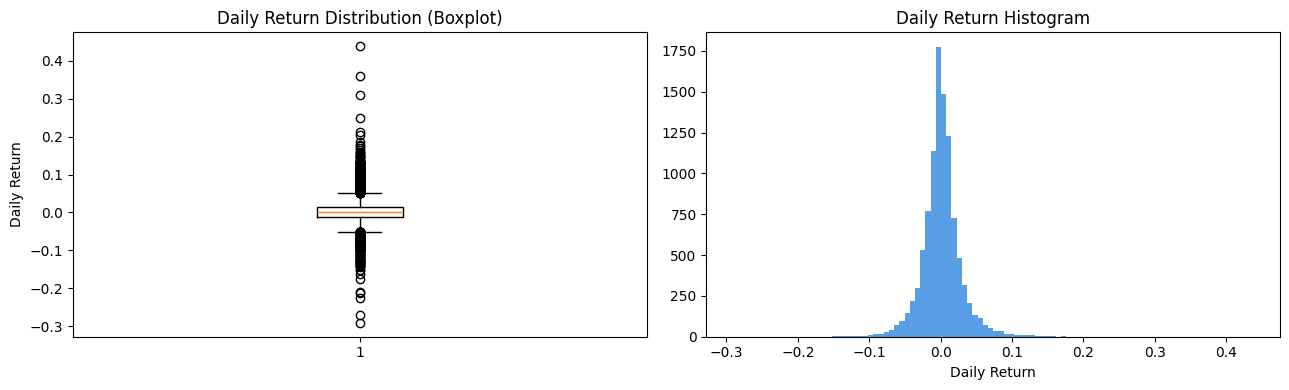

time
2025-06-12 00:00:00+00:00    0.133122
2025-09-10 00:00:00+00:00    0.359488
2025-12-11 00:00:00+00:00   -0.108336
2026-02-09 00:00:00+00:00    0.096415
2026-03-11 00:00:00+00:00    0.091834
2026-04-13 00:00:00+00:00    0.126946
2026-05-29 00:00:00+00:00    0.108395
2026-06-01 00:00:00+00:00    0.099079
2026-06-05 00:00:00+00:00   -0.095879
2026-08-03 00:00:00+00:00    0.092246
Name: close, dtype: float64

In [7]:
# Outlier check on daily returns using the IQR rule (a wide 3x IQR fence, since
# markets are naturally fat-tailed and a normal 1.5x fence would flag ~5% of all days).
returns_check = df['close'].pct_change().dropna()
q1, q3 = returns_check.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence, upper_fence = q1 - 3 * iqr, q3 + 3 * iqr
outliers = returns_check[(returns_check < lower_fence) | (returns_check > upper_fence)]

print(f'IQR outlier fence: [{lower_fence:.4f}, {upper_fence:.4f}]')
print(f'Flagged {len(outliers)} extreme daily moves out of {len(returns_check)} ({len(outliers) / len(returns_check) * 100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].boxplot(returns_check, vert=True)
axes[0].set_title('Daily Return Distribution (Boxplot)')
axes[0].set_ylabel('Daily Return')

axes[1].hist(returns_check, bins=100, color='#2E86DE', alpha=0.8)
axes[1].set_title('Daily Return Histogram')
axes[1].set_xlabel('Daily Return')
plt.tight_layout()
plt.show()

# Decision: keep every flagged point. They correspond to genuine market events
# (earnings surprises, crashes, split-adjustment edges), not data-entry errors -
# removing them would understate real swing-trading risk rather than "clean" the data.
outliers.tail(10)

#### 6.3 Trend Visualisation

Candlestick chart with 6 SMA overlays - interactive (full history) and static (last 5 years).

In [8]:
# Oracle Trend Plot with candlesticks and 6 SMA overlays
import plotly.graph_objects as go

# Use the cleaned dataset when available; otherwise create a synthetic example.
if "df" in globals() and not df.empty:
    trend_df = df.reset_index().rename(columns={"time": "Date"})
    trend_df = trend_df[["Date", "open", "high", "low", "close"]].copy()
    trend_df["Date"] = pd.to_datetime(trend_df["Date"])
else:
    np.random.seed(42)
    dates = pd.date_range(start="2020-01-01", periods=900, freq="D")
    base_price = 40 + np.cumsum(np.random.normal(0, 1.5, len(dates)))
    opens = base_price.copy()
    closes = opens + np.random.normal(0, 1.1, len(dates))
    highs = np.maximum(opens, closes) + np.abs(np.random.normal(0, 2.0, len(dates)))
    lows = np.minimum(opens, closes) - np.abs(np.random.normal(0, 2.0, len(dates)))
    trend_df = pd.DataFrame({
        "Date": dates,
        "open": opens,
        "high": highs,
        "low": lows,
        "close": closes,
    })

# Ensure chronological ordering
trend_df = trend_df.sort_values("Date").dropna(subset=["open", "high", "low", "close"]).reset_index(drop=True)

# Build the required 6 SMA columns if they are not already present.
sma_palette = {
    756: "gray",
    504: "white",
    252: "red",
    125: "green",
    63: "yellow",
    21: "blue",
}

for window, color in sma_palette.items():
    column_name = f"SMA_{window}_Close"
    if column_name not in trend_df.columns:
        trend_df[column_name] = trend_df["close"].rolling(window=window, min_periods=1).mean()

# Create the candlestick trend chart.
fig = go.Figure()

fig.add_trace(
    go.Candlestick(
        x=trend_df["Date"],
        open=trend_df["open"],
        high=trend_df["high"],
        low=trend_df["low"],
        close=trend_df["close"],
        name="Oracle Candlesticks",
        increasing_line_color="#2ecc71",
        decreasing_line_color="#e74c3c",
        increasing_fillcolor="#2ecc71",
        decreasing_fillcolor="#e74c3c",
        line=dict(width=1),
        whiskerwidth=0.6,
        hoverlabel=dict(bgcolor="black")
    )
)

# Overlay the required moving averages.
for window, color in sma_palette.items():
    column_name = f"SMA_{window}_Close"
    fig.add_trace(
        go.Scatter(
            x=trend_df["Date"],
            y=trend_df[column_name],
            mode="lines",
            name=f"{column_name}",
            line=dict(color=color, width=1.6),
            hovertemplate=f"%{{x|%Y-%m-%d}}<br>{column_name}: %{{y:.2f}}<extra></extra>"
        )
    )

fig.update_layout(  # pyright: ignore[reportUnknownMemberType]
    title=dict(
        text="Oracle (ORCL) Trend Plot",
        x=0.5,
        font=dict(color="white", size=20)
    ),
    xaxis=dict(
        title=dict(
            text="Date",
            font=dict(color="white")
        ),
        tickfont=dict(color="white"),
        showgrid=True,
        gridcolor="rgba(255,255,255,0.08)",
        rangeslider=dict(visible=False)
    ),
    yaxis=dict(
        title=dict(
            text="Price (USD)",
            font=dict(color="white")
        ),
        tickfont=dict(color="white"),
        showgrid=True,
        gridcolor="rgba(255,255,255,0.08)"
    ),
    paper_bgcolor="black",
    plot_bgcolor="black",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
        font=dict(color="white", size=11)
    ),
    font=dict(color="white"),
    template="plotly_dark",
    margin=dict(l=10, r=10, t=60, b=10)
)

fig.show()


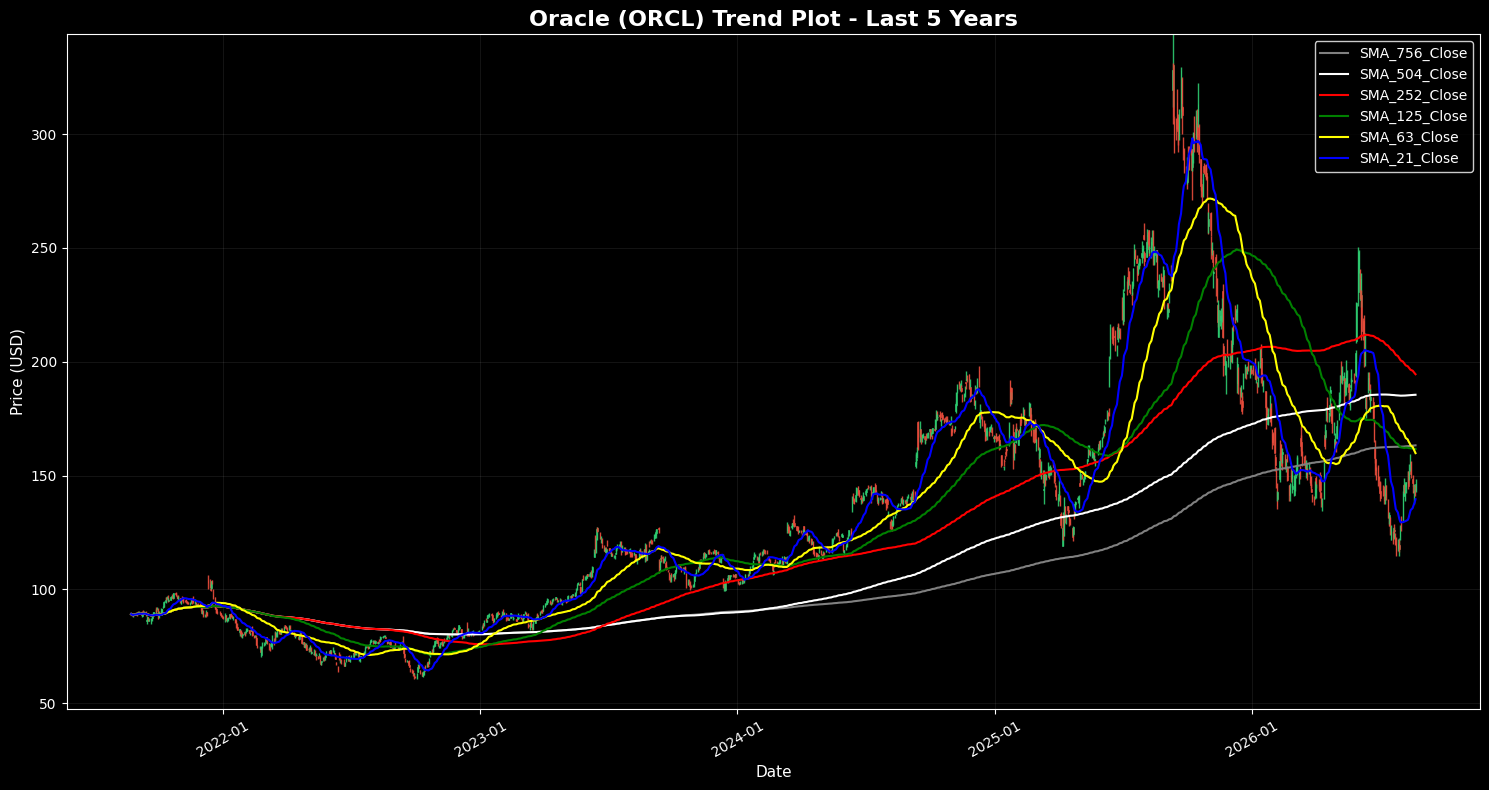

In [9]:
# Static ORCL trend chart for the last 5 years
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use the cleaned dataframe if available; otherwise create a fallback sample dataset.
if 'df' in globals() and not df.empty:
    static_df = df.reset_index().rename(columns={'time': 'Date'})
    static_df = static_df[['Date', 'open', 'high', 'low', 'close']].copy()
    static_df['Date'] = pd.to_datetime(static_df['Date'])
else:
    np.random.seed(42)
    dates = pd.date_range(start='2020-01-01', periods=1825, freq='D')
    base = 30 + np.cumsum(np.random.normal(0, 1.8, len(dates)))
    opens = base.copy()
    closes = opens + np.random.normal(0, 1.3, len(dates))
    highs = np.maximum(opens, closes) + np.abs(np.random.normal(0, 2.2, len(dates)))
    lows = np.minimum(opens, closes) - np.abs(np.random.normal(0, 2.2, len(dates)))
    static_df = pd.DataFrame({
        'Date': dates,
        'open': opens,
        'high': highs,
        'low': lows,
        'close': closes,
    })

# Restrict to the last 5 years.
cutoff = pd.Timestamp.today().normalize() - pd.DateOffset(years=5)
static_df: pd.DataFrame

# Ensure the Date column is timezone-aware UTC everywhere
static_df["Date"] = pd.to_datetime(static_df["Date"], utc=True, errors="coerce")
static_df = static_df.dropna(subset=["Date"]).copy()

# Keep the cutoff in UTC to match the datetime64[ns, UTC] data
cutoff = pd.Timestamp.now(tz="UTC").normalize() - pd.DateOffset(years=5)

static_df = (
    static_df.loc[static_df["Date"] >= cutoff]
    .sort_values(by="Date", ascending=True, kind="mergesort")
    .reset_index(drop=True)
)

# Compute moving averages in the required names.
for window in [756, 504, 252, 125, 63, 21]:
    static_df[f'SMA_{window}_Close'] = static_df['close'].rolling(window=window, min_periods=1).mean()

# Build the figure.
fig, ax = plt.subplots(figsize=(15, 8), facecolor='black')
ax.set_facecolor('black')

# Plot candlesticks.
for i in range(len(static_df)):
    o = static_df.iloc[i]['open']
    c = static_df.iloc[i]['close']
    h = static_df.iloc[i]['high']
    l = static_df.iloc[i]['low']
    color = '#2ecc71' if c >= o else '#e74c3c'
    x = mdates.date2num(static_df.iloc[i]['Date'])
    ax.vlines(x, l, h, color=color, linewidth=1.0, alpha=0.9)
    rect = plt.Rectangle(
        (x - 0.35, min(o, c)),
        0.7,
        max(abs(c - o), 0.01),
        facecolor=color,
        edgecolor=color,
        linewidth=0.5,
        alpha=0.9,
    )
    ax.add_patch(rect)

# Plot SMAs with the required colors.
line_colors = {
    'SMA_756_Close': 'gray',
    'SMA_504_Close': 'white',
    'SMA_252_Close': 'red',
    'SMA_125_Close': 'green',
    'SMA_63_Close': 'yellow',
    'SMA_21_Close': 'blue',
}

for column, color in line_colors.items():
    ax.plot(static_df['Date'], static_df[column], color=color, linewidth=1.5, label=column)

# Style the chart.
ax.set_title('Oracle (ORCL) Trend Plot - Last 5 Years', color='white', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', color='white', fontsize=11)
ax.set_ylabel('Price (USD)', color='white', fontsize=11)
ax.tick_params(axis='x', colors='white', labelrotation=30)
ax.tick_params(axis='y', colors='white')
ax.grid(True, color='white', alpha=0.08)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

for spine in ax.spines.values():
    spine.set_color('white')

legend = ax.legend(loc='upper right', frameon=True, facecolor='black', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()


#### 6.4 Correlation & Distribution

Correlation heatmap and scatter plot; motivates the PCA step in Section 9.6 given high SMA collinearity.

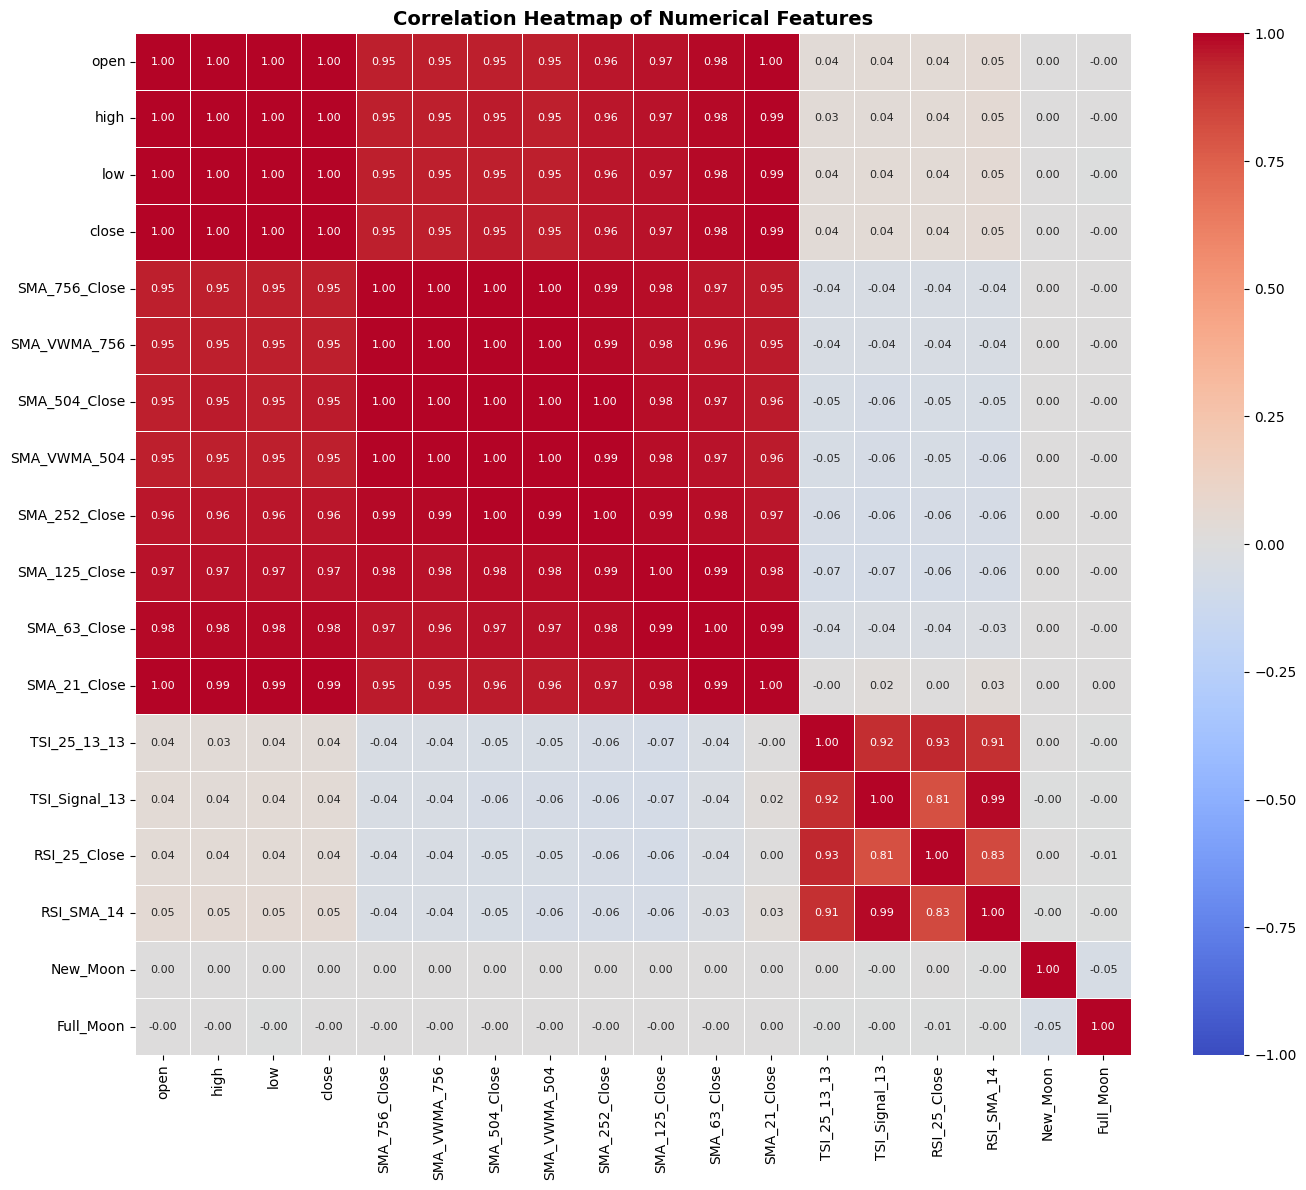

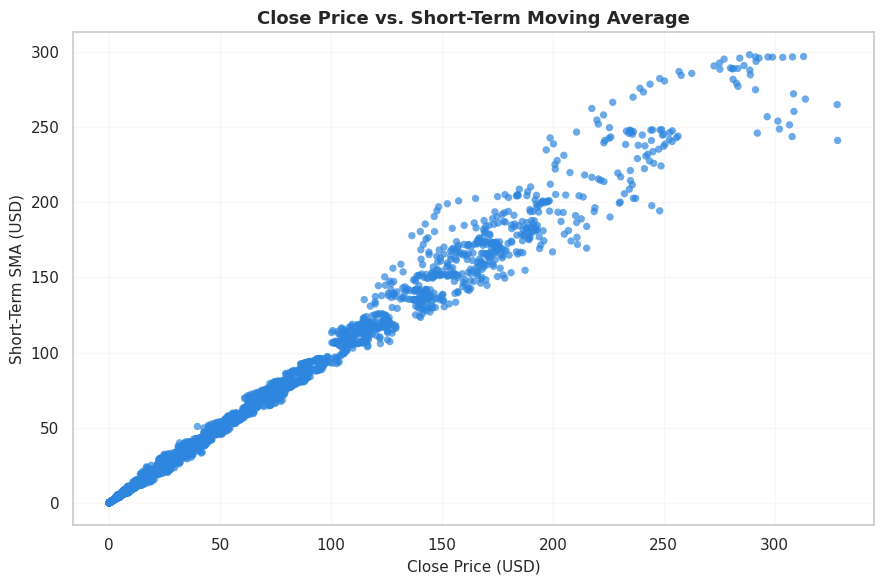

In [10]:
# Correlation heatmap, scatter/histogram, and historical seasonality table
import seaborn as sns

# Use the cleaned dataset for analysis.
df_model = df.copy()

# 1) Correlation heatmap with annotations
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df_model[numeric_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar=True,
    square=False,
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# 2) Scatter plot (close vs. short-term SMA)
scatter_cols = ['close', 'SMA_21_Close'] if 'SMA_21_Close' in df_model.columns else ['close', 'SMA_63_Close']
if len(scatter_cols) == 2:
    x_col, y_col = scatter_cols
    sns.set_theme(style='whitegrid')

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.scatterplot(
        data=df_model,
        x=x_col,
        y=y_col,
        ax=ax,
        s=28,
        alpha=0.7,
        color='#2E86DE',
        edgecolor='none'
    )

    ax.set_title('Close Price vs. Short-Term Moving Average', fontsize=13, weight='bold')
    ax.set_xlabel('Close Price (USD)', fontsize=11)
    ax.set_ylabel('Short-Term SMA (USD)', fontsize=11)
    ax.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.show()
else:
    print('Insufficient numeric columns for scatter plot view.')


#### 6.5 Historical Seasonality

Monthly/annual return table, colour-coded.

In [11]:
from IPython.display import display, HTML

seasonality_df = df_model.copy()
seasonality_df["year"] = seasonality_df.index.year
seasonality_df["month"] = seasonality_df.index.month

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

monthly = seasonality_df.groupby(["year", "month"]).agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_month=("close", "std"),
    avg_vol_month=("volume", "mean") if "volume" in seasonality_df.columns else ("close", "std")
)
monthly["ret_month_pct"] = ((monthly["close_end"] - monthly["open_start"]) / monthly["open_start"]) * 100

annual = seasonality_df.groupby("year").agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_year=("close", "std"),
    avg_vol_year=("volume", "mean") if "volume" in seasonality_df.columns else ("close", "std")
)
annual["ret_year_pct"] = ((annual["close_end"] - annual["open_start"]) / annual["open_start"]) * 100

seasonality_rows = sorted(seasonality_df["year"].unique())
seasonality_cols = [month_names[m] for m in range(1, 13)] + ["Annual"]

table_data = []

for yr in seasonality_rows:
    row = []
    for m in range(1, 13):
        month_key = (yr, m)
        if month_key in monthly.index:
            value = monthly.loc[month_key, "ret_month_pct"]
            row.append(f"{value:.1f}%")
        else:
            row.append("")
    row.append(f"{annual.loc[yr, 'ret_year_pct']:.1f}%")
    table_data.append(row)

seasonality_table = pd.DataFrame(table_data, index=seasonality_rows, columns=seasonality_cols)
seasonality_table.index.name = "Year"

display(HTML("""
<div style="font-family: Arial, sans-serif; margin-bottom: 10px;">
    <div style="font-size: 15px; font-weight: 700; color: #111111;">
        Oracle (ORCL) Historical Seasonality Table with Monthly and Annual Return Percentages
    </div>
</div>
"""))

def color_return(value):
    if pd.isna(value) or str(value).strip() == "":
        return "background-color: white; color: #111111"
    value_num = float(str(value).replace("%", ""))
    if value_num > 0:
        return "background-color: #d9f2dd; color: #111111"
    elif value_num < 0:
        return "background-color: #f9d7d5; color: #111111"
    return "background-color: white; color: #111111"

styled_table = (
    seasonality_table.style
    .set_properties(**{
        "background-color": "white",
        "color": "#111111",
        "border": "1px solid #d9d9d9",
        "padding": "8px 10px",
        "text-align": "center",
        "font-size": "12px"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#f5f5f5"),
            ("color", "#111111"),
            ("font-weight", "bold"),
            ("border", "1px solid #d9d9d9"),
            ("padding", "8px 10px")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid #d9d9d9"),
            ("padding", "8px 10px")
        ]}
    ])
    .applymap(color_return)
)

styled_table

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
Year,,,,,,,,,,,,,
1986,,,1.2%,26.6%,-6.0%,3.7%,-36.4%,6.5%,-13.6%,26.3%,21.1%,-3.5%,1.2%
1987,30.1%,42.6%,14.3%,6.8%,16.0%,-18.3%,2.2%,17.6%,21.5%,-23.1%,-13.0%,33.3%,179.5%
1988,-3.4%,8.0%,7.4%,3.1%,0.0%,17.9%,-3.8%,-2.6%,8.8%,-21.7%,9.5%,13.0%,34.5%
1989,21.2%,-4.8%,7.2%,20.2%,6.1%,-2.5%,-0.8%,22.0%,26.0%,-1.6%,3.2%,-2.6%,139.7%
1990,-8.0%,4.1%,-15.6%,-15.9%,24.4%,17.1%,-27.0%,-31.1%,-44.1%,-17.3%,46.5%,0.0%,-66.3%
1991,14.3%,0.0%,1.4%,2.8%,-18.9%,13.3%,7.4%,23.3%,18.9%,17.8%,-14.3%,7.4%,84.1%
1992,27.6%,8.1%,-32.1%,3.7%,7.2%,3.4%,11.2%,-4.8%,14.3%,11.9%,0.0%,27.5%,95.7%
1993,15.0%,0.4%,11.4%,-2.7%,16.8%,18.0%,2.3%,2.7%,19.2%,-3.5%,6.5%,-10.9%,103.5%
1994,11.7%,2.7%,-3.4%,-4.8%,14.2%,9.9%,2.0%,11.2%,1.5%,6.7%,-9.8%,7.6%,53.5%


#### 6.6 Support & Resistance

Percentile-based support/resistance, full history and last 5 years.

Oracle (ORCL) Support and Resistance Levels:
Strong Support (10th percentile): $0.29
Support (25th percentile): $3.60
Median Price: $18.73
Mean Price: $33.66
Resistance (75th percentile): $42.06
Strong Resistance (90th percentile): $86.90


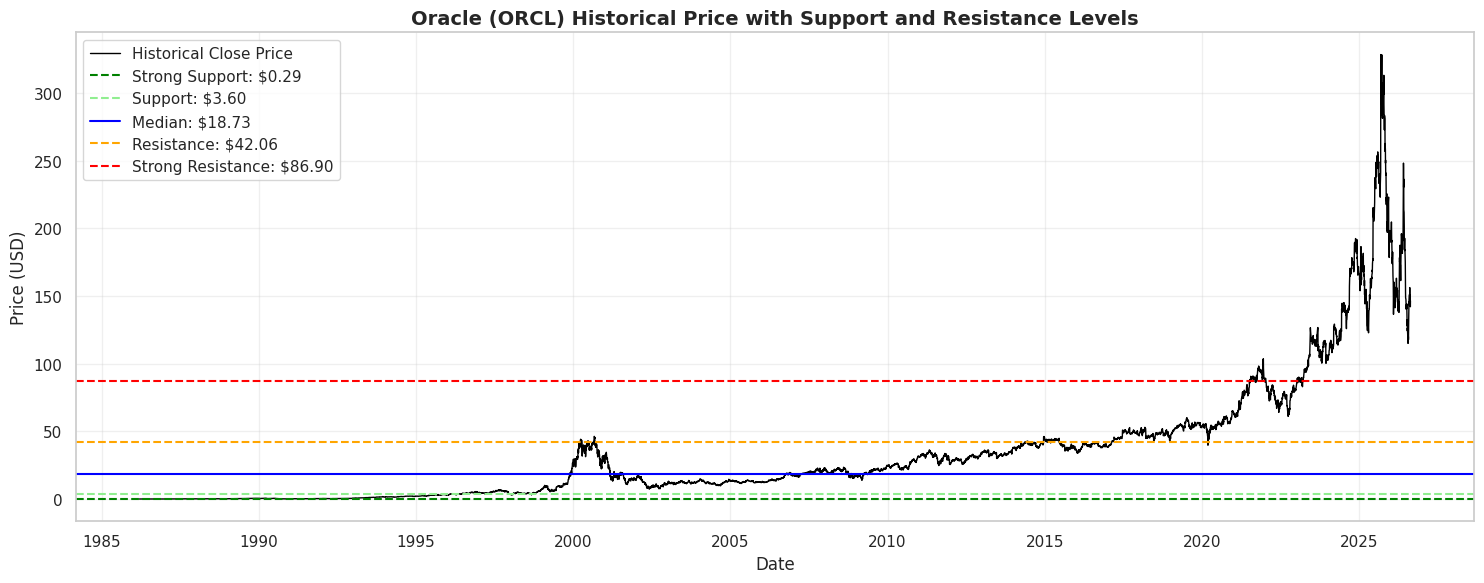

Current Price: $146.47
Distance to Strong Support: 99.80%
Distance to Resistance: -71.28%


In [12]:
# Support and resistance analysis using the complete historical ORCL price data
historical_close = pd.to_numeric(df_model['close'], errors='coerce').dropna()

# Calculate support and resistance levels using percentile analysis.
support_level_1 = historical_close.quantile(0.10)
support_level_2 = historical_close.quantile(0.25)
resistance_level_1 = historical_close.quantile(0.75)
resistance_level_2 = historical_close.quantile(0.90)

median_price = historical_close.median()
mean_price = historical_close.mean()

print('Oracle (ORCL) Support and Resistance Levels:')
print(f'Strong Support (10th percentile): ${support_level_1:.2f}')
print(f'Support (25th percentile): ${support_level_2:.2f}')
print(f'Median Price: ${median_price:.2f}')
print(f'Mean Price: ${mean_price:.2f}')
print(f'Resistance (75th percentile): ${resistance_level_1:.2f}')
print(f'Strong Resistance (90th percentile): ${resistance_level_2:.2f}')

# Plot the complete historical close-price series without moving averages.
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(
    historical_close.index,
    historical_close,
    label='Historical Close Price',
    linewidth=1.0,
    color='black'
)

ax.axhline(
    y=support_level_1,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'Strong Support: ${support_level_1:.2f}'
)
ax.axhline(
    y=support_level_2,
    color='lightgreen',
    linestyle='--',
    linewidth=1.5,
    label=f'Support: ${support_level_2:.2f}'
)
ax.axhline(
    y=median_price,
    color='blue',
    linestyle='-',
    linewidth=1.5,
    label=f'Median: ${median_price:.2f}'
)
ax.axhline(
    y=resistance_level_1,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label=f'Resistance: ${resistance_level_1:.2f}'
)
ax.axhline(
    y=resistance_level_2,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Strong Resistance: ${resistance_level_2:.2f}'
)

ax.set_title('Oracle (ORCL) Historical Price with Support and Resistance Levels', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
fig.tight_layout()
plt.show()

current_price = historical_close.iloc[-1]
support_distance = ((current_price - support_level_1) / current_price) * 100
resistance_distance = ((resistance_level_1 - current_price) / current_price) * 100

print(f'Current Price: ${current_price:.2f}')
print(f'Distance to Strong Support: {support_distance:.2f}%')
print(f'Distance to Resistance: {resistance_distance:.2f}%')

Oracle (ORCL) Five-Year Support and Resistance Levels:
Strong Support (5th percentile): $71.75
Support (10th percentile): $76.37
Support (25th percentile): $88.94
Median Price: $117.23
Mean Price: $132.68
Resistance (75th percentile): $165.28
Resistance (90th percentile): $205.09
Strong Resistance (95th percentile): $243.62


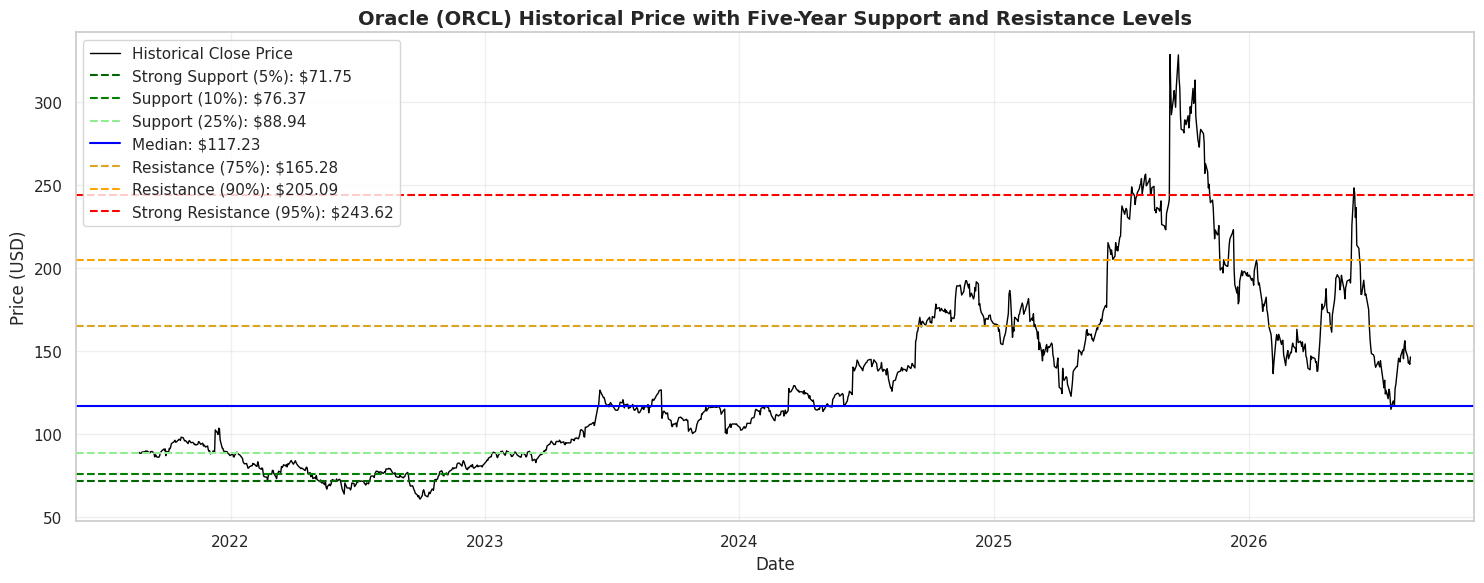

Current Price: $146.47
Distance to Strong Support: 51.01%
Distance to Resistance: 12.85%


In [13]:
# Five-year support and resistance analysis with additional percentile levels
five_year_close = pd.to_numeric(df_model['close'], errors='coerce').dropna().copy()
five_year_close.index = pd.to_datetime(five_year_close.index, utc=True, errors='coerce')
five_year_close = five_year_close[five_year_close.index.notna()]

five_year_cutoff = pd.Timestamp.now(tz='UTC').normalize() - pd.DateOffset(years=5)
five_year_close = five_year_close.loc[five_year_close.index >= five_year_cutoff]

# Calculate additional support and resistance levels from the last five years.
support_level_1 = five_year_close.quantile(0.05)
support_level_2 = five_year_close.quantile(0.10)
support_level_3 = five_year_close.quantile(0.25)
resistance_level_1 = five_year_close.quantile(0.75)
resistance_level_2 = five_year_close.quantile(0.90)
resistance_level_3 = five_year_close.quantile(0.95)
median_price = five_year_close.median()
mean_price = five_year_close.mean()

print('Oracle (ORCL) Five-Year Support and Resistance Levels:')
print(f'Strong Support (5th percentile): ${support_level_1:.2f}')
print(f'Support (10th percentile): ${support_level_2:.2f}')
print(f'Support (25th percentile): ${support_level_3:.2f}')
print(f'Median Price: ${median_price:.2f}')
print(f'Mean Price: ${mean_price:.2f}')
print(f'Resistance (75th percentile): ${resistance_level_1:.2f}')
print(f'Resistance (90th percentile): ${resistance_level_2:.2f}')
print(f'Strong Resistance (95th percentile): ${resistance_level_3:.2f}')

# Plot the last five years of historical close prices without moving averages.
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(
    five_year_close.index,
    five_year_close,
    label='Historical Close Price',
    linewidth=1.0,
    color='black'
)

levels = [
    (support_level_1, 'darkgreen', 'Strong Support (5%)'),
    (support_level_2, 'green', 'Support (10%)'),
    (support_level_3, 'lightgreen', 'Support (25%)'),
    (median_price, 'blue', 'Median'),
    (resistance_level_1, 'goldenrod', 'Resistance (75%)'),
    (resistance_level_2, 'orange', 'Resistance (90%)'),
    (resistance_level_3, 'red', 'Strong Resistance (95%)')
]

for level, color, label in levels:
    line_style = '-' if label == 'Median' else '--'
    ax.axhline(
        y=level,
        color=color,
        linestyle=line_style,
        linewidth=1.5,
        label=f'{label}: ${level:.2f}'
    )

ax.set_title('Oracle (ORCL) Historical Price with Five-Year Support and Resistance Levels', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
fig.tight_layout()
plt.show()

current_price = five_year_close.iloc[-1]
support_distance = ((current_price - support_level_1) / current_price) * 100
resistance_distance = ((resistance_level_1 - current_price) / current_price) * 100

print(f'Current Price: ${current_price:.2f}')
print(f'Distance to Strong Support: {support_distance:.2f}%')
print(f'Distance to Resistance: {resistance_distance:.2f}%')

#### 6.7 Hypothesis Testing (Week 2)

Stationarity test (ADF), RSI-regime forward-return test, and a moon-phase test (Section 6.7b).

In [14]:
# Augmented Dickey-Fuller test: is the price series stationary, or do we need returns?
price_adf = adfuller(df['close'].dropna())
returns_adf = adfuller(df['close'].pct_change().dropna())

print('ADF test - Close Price:  statistic=%.3f, p-value=%.4f' % (price_adf[0], price_adf[1]))
print('ADF test - Daily Return: statistic=%.3f, p-value=%.4f' % (returns_adf[0], returns_adf[1]))

# H0: the series has a unit root (non-stationary). Prices are expected to fail to
# reject H0 (trending, non-stationary), while returns should reject H0 (stationary).
# This justifies engineering returns/labels as model inputs instead of raw price levels.

ADF test - Close Price:  statistic=-0.992, p-value=0.7562
ADF test - Daily Return: statistic=-28.492, p-value=0.0000


In [15]:
# Hypothesis test: do RSI oversold/overbought regimes produce different forward returns?
# (Uses the same 21-trading-day swing horizon defined formally in Feature Engineering below -
# roughly one trading month, matching the forecast horizon used throughout this notebook.)
SWING_HORIZON = 21
hyp_df = df[['close', 'RSI_25_Close']].copy()
hyp_df['forward_return'] = hyp_df['close'].shift(-SWING_HORIZON) / hyp_df['close'] - 1

oversold_returns = hyp_df.loc[hyp_df['RSI_25_Close'] < 30, 'forward_return'].dropna()
overbought_returns = hyp_df.loc[hyp_df['RSI_25_Close'] > 70, 'forward_return'].dropna()

t_stat, p_value = stats.ttest_ind(oversold_returns, overbought_returns, equal_var=False)

print(f'Oversold (RSI<30) mean {SWING_HORIZON}-day forward return: {oversold_returns.mean() * 100:.2f}% (n={len(oversold_returns)})')
print(f'Overbought (RSI>70) mean {SWING_HORIZON}-day forward return: {overbought_returns.mean() * 100:.2f}% (n={len(overbought_returns)})')
print(f"Welch's t-test: t={t_stat:.3f}, p={p_value:.4f}")

# H0: mean forward return is equal in both RSI regimes.
# A p-value below 0.05 supports using RSI as a genuine swing-trading signal, not noise.

# Quick placebo comparison: repeat the same test on the Full_Moon flag, which has no
# fundamental reason to predict returns - a non-significant result here is expected
# and demonstrates the test can tell a real signal apart from a spurious one. A much
# more thorough moon-phase investigation, prompted by a specific pattern noticed in
# the 2026 data, follows immediately below.
moon_df = df[['close', 'Full_Moon']].copy()
moon_df['forward_return'] = moon_df['close'].shift(-SWING_HORIZON) / moon_df['close'] - 1
moon_returns = moon_df.loc[moon_df['Full_Moon'] == 1, 'forward_return'].dropna()
no_moon_returns = moon_df.loc[moon_df['Full_Moon'] == 0, 'forward_return'].dropna()
moon_t, moon_p = stats.ttest_ind(moon_returns, no_moon_returns, equal_var=False)
print(f"\nPlacebo check - Full Moon vs. rest, Welch's t-test: t={moon_t:.3f}, p={moon_p:.4f}")

Oversold (RSI<30) mean 21-day forward return: -2.91% (n=45)
Overbought (RSI>70) mean 21-day forward return: 6.92% (n=161)
Welch's t-test: t=-3.410, p=0.0011

Placebo check - Full Moon vs. rest, Welch's t-test: t=0.360, p=0.7188


#### 6.7b Does ORCL Move With the Moon?

Verifies two specific 2026 moves against the raw data, then tests the pattern across the full 40-year history.

In [16]:
# Correlation and group-mean comparison across every New Moon / Full Moon day in the
# full 40-year history (n ~= 500 of each), not just the two dates noticed above.
for horizon in [10, 21]:
    fwd = df['close'].shift(-horizon) / df['close'] - 1
    moon_check = pd.DataFrame({
        'fwd_return': fwd,
        'New_Moon': df['New_Moon'],
        'Full_Moon': df['Full_Moon'],
    }).dropna()

    corr_new = moon_check['fwd_return'].corr(moon_check['New_Moon'])
    corr_full = moon_check['fwd_return'].corr(moon_check['Full_Moon'])

    new_moon_ret = moon_check.loc[moon_check['New_Moon'] == 1, 'fwd_return']
    full_moon_ret = moon_check.loc[moon_check['Full_Moon'] == 1, 'fwd_return']
    neither_ret = moon_check.loc[(moon_check['New_Moon'] == 0) & (moon_check['Full_Moon'] == 0), 'fwd_return']

    t_new, p_new = stats.ttest_ind(new_moon_ret, neither_ret, equal_var=False)
    t_full, p_full = stats.ttest_ind(full_moon_ret, neither_ret, equal_var=False)

    print(f'--- {horizon}-trading-day forward return ---')
    print(f'Pearson r, New_Moon flag:  {corr_new:+.4f}')
    print(f'Pearson r, Full_Moon flag: {corr_full:+.4f}')
    print(f'New Moon days:  mean={new_moon_ret.mean()*100:+.2f}%  median={new_moon_ret.median()*100:+.2f}%  (n={len(new_moon_ret)})')
    print(f'Full Moon days: mean={full_moon_ret.mean()*100:+.2f}%  median={full_moon_ret.median()*100:+.2f}%  (n={len(full_moon_ret)})')
    print(f'Neither:        mean={neither_ret.mean()*100:+.2f}%  (n={len(neither_ret)})')
    print(f'Welch t-test, New Moon vs. Neither:  t={t_new:.3f}, p={p_new:.4f}')
    print(f'Welch t-test, Full Moon vs. Neither: t={t_full:.3f}, p={p_full:.4f}')
    print()

--- 10-trading-day forward return ---
Pearson r, New_Moon flag:  -0.0006
Pearson r, Full_Moon flag: +0.0060
New Moon days:  mean=+1.11%  median=+0.51%  (n=499)
Full Moon days: mean=+1.37%  median=+0.97%  (n=500)
Neither:        mean=+1.13%  (n=9176)
Welch t-test, New Moon vs. Neither:  t=-0.031, p=0.9753
Welch t-test, Full Moon vs. Neither: t=0.617, p=0.5372

--- 21-trading-day forward return ---
Pearson r, New_Moon flag:  +0.0045
Pearson r, Full_Moon flag: +0.0037
New Moon days:  mean=+2.66%  median=+1.72%  (n=499)
Full Moon days: mean=+2.61%  median=+1.67%  (n=499)
Neither:        mean=+2.38%  (n=9166)
Welch t-test, New Moon vs. Neither:  t=0.476, p=0.6340
Welch t-test, Full Moon vs. Neither: t=0.383, p=0.7016



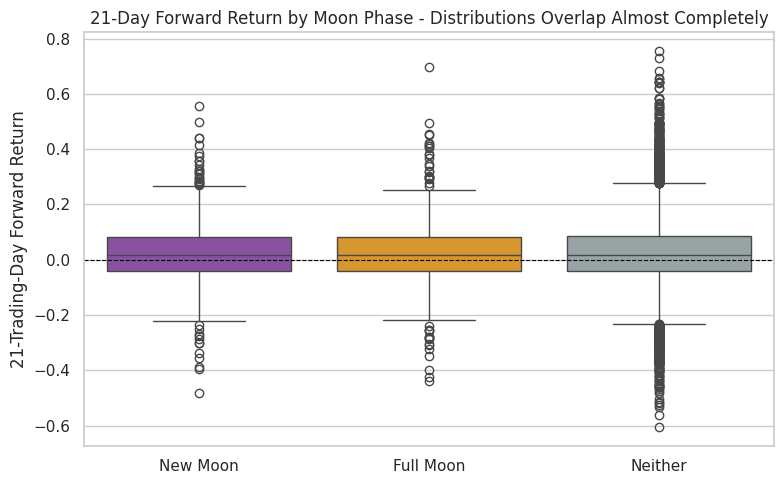

In [17]:
# Visualise the same comparison: forward-return distribution by moon phase,
# at the 21-trading-day horizon used throughout this notebook.
fwd21_all = df['close'].shift(-21) / df['close'] - 1
moon_groups = pd.DataFrame({'fwd_return': fwd21_all, 'New_Moon': df['New_Moon'], 'Full_Moon': df['Full_Moon']}).dropna()

moon_groups['Phase'] = 'Neither'
moon_groups.loc[moon_groups['New_Moon'] == 1, 'Phase'] = 'New Moon'
moon_groups.loc[moon_groups['Full_Moon'] == 1, 'Phase'] = 'Full Moon'

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=moon_groups, x='Phase', y='fwd_return', order=['New Moon', 'Full Moon', 'Neither'],
            palette={'New Moon': '#8e44ad', 'Full Moon': '#f39c12', 'Neither': '#95a5a6'}, ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('21-Day Forward Return by Moon Phase - Distributions Overlap Almost Completely')
ax.set_xlabel('')
ax.set_ylabel('21-Trading-Day Forward Return')
plt.tight_layout()
plt.show()

In [18]:
# Is a +37% / -14% swing over ~2-3 weeks actually unusual for ORCL, or does the stock
# move this much regularly in its current (2025-2026) regime regardless of moon phase?
roll11 = (df['close'].shift(-11) / df['close'] - 1).dropna()
big_move_rate_all = (roll11.abs() > 0.30).mean()
recent11 = roll11.loc['2025-01-01':]
big_move_rate_recent = (recent11.abs() > 0.30).mean()

print(f'11-trading-day forward return, full history: mean={roll11.mean()*100:.2f}%, std={roll11.std()*100:.2f}%')
print(f'Share of ALL historical 11-day windows with a >30% move (up or down): {big_move_rate_all*100:.2f}%')
print(f'Same share, restricted to 2025-01-01 onward only: {big_move_rate_recent*100:.2f}%')
print(f'-> a move this size is roughly {big_move_rate_recent/big_move_rate_all:.1f}x more common in the current')
print('   regime than across the stock\'s full history - consistent with an unusually volatile')
print('   2025-2026 stretch (plausibly news/earnings driven), not a lunar effect.')

11-trading-day forward return, full history: mean=1.25%, std=9.15%
Share of ALL historical 11-day windows with a >30% move (up or down): 1.51%
Same share, restricted to 2025-01-01 onward only: 3.26%
-> a move this size is roughly 2.2x more common in the current
   regime than across the stock's full history - consistent with an unusually volatile
   2025-2026 stretch (plausibly news/earnings driven), not a lunar effect.


**Verdict:** No significant moon-phase effect across ~40 years (all p > 0.6); the two 2026 anecdotes coincide with an unusually volatile period, not a lunar cause. Full discussion in the written report, Section 4.4.

### 7. Feature Engineering

Builds the model feature matrix (returns, volatility, distance-from-SMA, RSI/TSI) and a 3-class Buy/Hold/Sell label over a 21-day horizon (+/-5% threshold).

In [19]:
# Build supervised-learning features and swing-trading target labels
model_df = df_model.copy()

# Daily and log returns capture momentum better than raw price levels (see ADF test above)
model_df['return_1d'] = model_df['close'].pct_change()
model_df['log_return_1d'] = np.log(model_df['close'] / model_df['close'].shift(1))

# Rolling volatility (20-day) as a risk/regime feature
model_df['volatility_20d'] = model_df['return_1d'].rolling(window=20).std()

# Distance of price from key moving averages (mean-reversion / trend-strength signal)
model_df['dist_sma21'] = (model_df['close'] - model_df['SMA_21_Close']) / model_df['SMA_21_Close']
model_df['dist_sma63'] = (model_df['close'] - model_df['SMA_63_Close']) / model_df['SMA_63_Close']
model_df['dist_sma252'] = (model_df['close'] - model_df['SMA_252_Close']) / model_df['SMA_252_Close']

# Momentum/oscillator features already supplied by the TradingView export
model_df['rsi'] = model_df['RSI_25_Close']
model_df['tsi'] = model_df['TSI_25_13_13']
model_df['tsi_signal'] = model_df['TSI_Signal_13']

# Swing-trading horizon: hold for 21 trading days (~1 trading month). This also matches
# the horizon used for the 21-day price-range forecast built in Section 10.
SWING_HORIZON = 21
BUY_THRESHOLD = 0.05    # +5% forward move -> Buy signal
SELL_THRESHOLD = -0.05  # -5% forward move -> Sell signal
# Thresholds were widened from +/-3% (used at the original 10-day horizon) to +/-5% here,
# since price naturally moves further over 21 days; +/-5% keeps the three classes at a
# reasonable 36% / 41% / 22% Buy/Hold/Sell balance instead of skewing heavily toward Buy.

model_df['forward_return'] = model_df['close'].shift(-SWING_HORIZON) / model_df['close'] - 1

def label_signal(r):
    if pd.isna(r):
        return np.nan
    if r >= BUY_THRESHOLD:
        return 1   # Buy
    if r <= SELL_THRESHOLD:
        return -1  # Sell
    return 0       # Hold

model_df['signal'] = model_df['forward_return'].apply(label_signal)

feature_cols = [
    'return_1d', 'volatility_20d', 'dist_sma21', 'dist_sma63', 'dist_sma252',
    'rsi', 'tsi', 'tsi_signal'
]

model_df = model_df.dropna(subset=feature_cols + ['signal']).copy()

print('Feature matrix shape:', model_df[feature_cols].shape)
print('\nSignal distribution (-1=Sell, 0=Hold, 1=Buy):\n', model_df['signal'].value_counts())
model_df[feature_cols + ['forward_return', 'signal']].tail(10)

Feature matrix shape: (9913, 8)

Signal distribution (-1=Sell, 0=Hold, 1=Buy):
 signal
 0.0    4121
 1.0    3573
-1.0    2219
Name: count, dtype: int64


,return_1d,volatility_20d,dist_sma21,dist_sma63,dist_sma252,rsi,tsi,tsi_signal,forward_return,signal
time,,,,,,,,,,
2026-07-10 00:00:00+00:00,-0.024823,0.030304,-0.132571,-0.220592,-0.322253,37.723173,-35.893577,-25.054272,0.074019,1.0
2026-07-13 00:00:00+00:00,-0.064704,0.028150,-0.171737,-0.270603,-0.364849,35.195424,-37.490160,-26.830827,0.105975,1.0
2026-07-14 00:00:00+00:00,-0.027368,0.027976,-0.180607,-0.288832,-0.381015,34.249683,-39.248891,-28.604837,0.198062,1.0
2026-07-15 00:00:00+00:00,0.035564,0.026771,-0.137889,-0.261553,-0.357809,36.496268,-39.398485,-30.146786,0.179108,1.0
2026-07-16 00:00:00+00:00,-0.062495,0.028545,-0.174259,-0.304898,-0.396657,34.276204,-40.548312,-31.632719,0.211819,1.0
2026-07-17 00:00:00+00:00,0.017712,0.029734,-0.142831,-0.289308,-0.384608,35.364407,-40.834022,-32.947190,0.160114,1.0
2026-07-20 00:00:00+00:00,-0.039791,0.029631,-0.160083,-0.314302,-0.407638,34.022782,-41.689126,-34.196038,0.176388,1.0
2026-07-21 00:00:00+00:00,0.046713,0.032289,-0.103948,-0.279005,-0.378542,36.836464,-40.681066,-35.122471,0.131917,1.0
2026-07-22 00:00:00+00:00,-0.009524,0.030809,-0.097561,-0.282294,-0.383051,36.490531,-40.019822,-35.822092,0.128973,1.0


### 8. Algorithm Selection

| Algorithm | Task |
|---|---|
| Dummy | Baseline |
| Logistic Regression | Classification |
| Neural Network | Classification |
| Random Forest | Classification |
| PCA + K-Means | Regime clustering |
| Gaussian HMM | Regime clustering (alternative) |
| LSTM / LSTM v2 | Sequence forecasting |
| Empirical quantile forecast | Decision support |
| ATR + nearest S/R engine | Decision support |

Full justification for each choice, including why not alternative models, is in the written report, Section 4.2.

### 9. Training & Evaluation

Trains and evaluates every model on a chronological, never-shuffled train/test split.

#### 9.1 Train/Test Split & Baseline

In [20]:
# Chronological train/test split - never shuffle time-series data (that would leak the future into training)
split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx]
test_df = model_df.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df['signal']
X_test, y_test = test_df[feature_cols], test_df['signal']

print(f'Train period: {train_df.index.min().date()} to {train_df.index.max().date()} ({len(train_df)} rows)')
print(f'Test period:  {test_df.index.min().date()} to {test_df.index.max().date()} ({len(test_df)} rows)')

# Scale features - required for Logistic Regression and the Neural Network, harmless for trees
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Class labels present, used consistently below for report/plot ordering
labels_order = sorted(model_df['signal'].unique())
label_names = {-1: 'Sell', 0: 'Hold', 1: 'Buy'}
target_names = [label_names[lbl] for lbl in labels_order]

# Baseline: predict the majority class every time - any real model must beat this
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train_scaled, y_train)
baseline_pred = baseline_model.predict(X_test_scaled)

print('\nBaseline accuracy:', round(accuracy_score(y_test, baseline_pred), 4))
print('Baseline balanced accuracy:', round(balanced_accuracy_score(y_test, baseline_pred), 4))

Train period: 1987-03-10 to 2018-08-29 (7930 rows)
Test period:  2018-08-30 to 2026-07-23 (1983 rows)

Baseline accuracy: 0.4347
Baseline balanced accuracy: 0.3333


#### 9.2 Logistic Regression (Week 4)

In [21]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression: linear, interpretable baseline for the 3-class swing signal.
# class_weight='balanced' compensates for Hold usually outnumbering Buy/Sell.
logreg_model = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_model.fit(X_train_scaled, y_train)
logreg_pred = logreg_model.predict(X_test_scaled)

print(classification_report(y_test, logreg_pred, labels=labels_order, target_names=target_names))

# Inspect which features push the model toward Buy vs. Sell
coef_table = pd.DataFrame(logreg_model.coef_, columns=feature_cols, index=[label_names[l] for l in logreg_model.classes_])
coef_table.round(3)

              precision    recall  f1-score   support

        Sell       0.40      0.19      0.26       451
        Hold       0.50      0.77      0.60       862
         Buy       0.39      0.26      0.31       670

    accuracy                           0.46      1983
   macro avg       0.43      0.40      0.39      1983
weighted avg       0.44      0.46      0.42      1983



,return_1d,volatility_20d,dist_sma21,dist_sma63,dist_sma252,rsi,tsi,tsi_signal
Sell,0.041,0.230,-0.436,0.336,-0.056,0.237,0.138,-0.305
Hold,-0.073,-0.432,0.387,-0.355,-0.082,0.246,-0.461,0.399
Buy,0.032,0.202,0.049,0.019,0.137,-0.483,0.323,-0.094


#### 9.3 Feed-Forward Neural Network Classifier (Week 3 & 4)

Tests non-linear indicator interactions against the linear Logistic Regression above.

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                288       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 3)                 51        
                                                                 
Total params: 867 (3.39 KB)
Trainable params: 867 (3.39 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-08-23 12:11:10.513239: I external/local_xla/xla/service/service.cc:168] XLA service 0x7b66b88f7900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-23 12:11:10.513266: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1050 Ti, Compute Capability 6.1
2026-08-23 12:11:10.525762: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-23 12:11:10.553088: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1787501470.640015    6809 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


              precision    recall  f1-score   support

        Sell       0.58      0.03      0.06       451
        Hold       0.49      0.84      0.62       862
         Buy       0.38      0.27      0.32       670

    accuracy                           0.46      1983
   macro avg       0.48      0.38      0.33      1983
weighted avg       0.47      0.46      0.39      1983



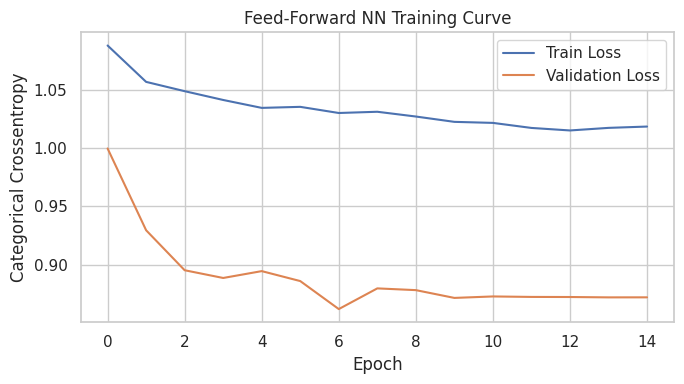

In [22]:
from tensorflow.keras.utils import to_categorical

# Feed-forward Neural Network: a small dense classifier for Sell / Hold / Buy.
# Labels are re-mapped from {-1, 0, 1} to {0, 1, 2} for categorical crossentropy.
label_to_index = {-1: 0, 0: 1, 1: 2}
index_to_label = {v: k for k, v in label_to_index.items()}

# Convert {-1, 0, 1} labels to {0, 1, 2} without pandas map type warnings.
y_train_indices = np.asarray(y_train, dtype=np.int64) + 1
y_test_indices = np.asarray(y_test, dtype=np.int64) + 1

y_train_nn = to_categorical(y_train_indices, num_classes=3)
y_test_nn = to_categorical(y_test.map(label_to_index), num_classes=3)

nn_classifier = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')  # Sell / Hold / Buy probabilities
])

nn_classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
nn_classifier.summary()

# EarlyStopping guards against overfitting on the smaller Buy/Sell classes
nn_history = nn_classifier.fit(
    X_train_scaled, y_train_nn,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(patience=8, restore_best_weights=True), ReduceLROnPlateau(patience=4)],
    verbose=0
)

nn_pred_probs = nn_classifier.predict(X_test_scaled, verbose=0)
nn_pred = pd.Series(np.argmax(nn_pred_probs, axis=1)).map(index_to_label).values

print(classification_report(y_test, nn_pred, labels=labels_order, target_names=target_names))

plt.figure(figsize=(7, 4))
plt.plot(nn_history.history['loss'], label='Train Loss')
plt.plot(nn_history.history['val_loss'], label='Validation Loss')
plt.title('Feed-Forward NN Training Curve')
plt.xlabel('Epoch')
plt.ylabel('Categorical Crossentropy')
plt.legend()
plt.tight_layout()
plt.show()

#### 9.4 Random Forest with Time-Series Cross-Validation

Non-linear benchmark; hyperparameters tuned via `GridSearchCV` over `TimeSeriesSplit`.

In [23]:
# Random Forest: captures feature interactions (e.g. RSI x volatility) a linear model cannot.
tscv = TimeSeriesSplit(n_splits=5)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 8],
    'min_samples_leaf': [5, 10, 20]
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='balanced_accuracy',
    n_jobs=-1
)
rf_search.fit(X_train_scaled, y_train)

print('Best RF params:', rf_search.best_params_)
rf_model = rf_search.best_estimator_
rf_pred = rf_model.predict(X_test_scaled)
print(classification_report(y_test, rf_pred, labels=labels_order, target_names=target_names))

# Feature importance - which indicators the forest actually splits on most
importance_table = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importance_table.round(3)

Best RF params: {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 100}
              precision    recall  f1-score   support

        Sell       0.33      0.18      0.24       451
        Hold       0.51      0.68      0.58       862
         Buy       0.40      0.35      0.38       670

    accuracy                           0.46      1983
   macro avg       0.41      0.40      0.40      1983
weighted avg       0.43      0.46      0.43      1983



volatility_20d    0.435
dist_sma21        0.136
dist_sma252       0.120
dist_sma63        0.106
rsi               0.072
tsi_signal        0.056
tsi               0.041
return_1d         0.034
dtype: float64

#### 9.5 Classifier Comparison

In [24]:
# Compare all classifiers on a shared set of metrics
models_compared = {
    'Baseline (Majority)': baseline_pred,
    'Logistic Regression': logreg_pred,
    'Neural Network': nn_pred,
    'Random Forest': rf_pred,
}

comparison_rows = []
for name, preds in models_compared.items():
    comparison_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Balanced Accuracy': balanced_accuracy_score(y_test, preds),
        'F1 (macro)': f1_score(y_test, preds, average='macro'),
    })

comparison_table = pd.DataFrame(comparison_rows).round(4).sort_values('Balanced Accuracy', ascending=False)
comparison_table

,Model,Accuracy,Balanced Accuracy,F1 (macro)
3,Random Forest,0.4554,0.4047,0.3982
1,Logistic Regression,0.4624,0.4039,0.3897
2,Neural Network,0.4639,0.3812,0.3326
0,Baseline (Majority),0.4347,0.3333,0.2020


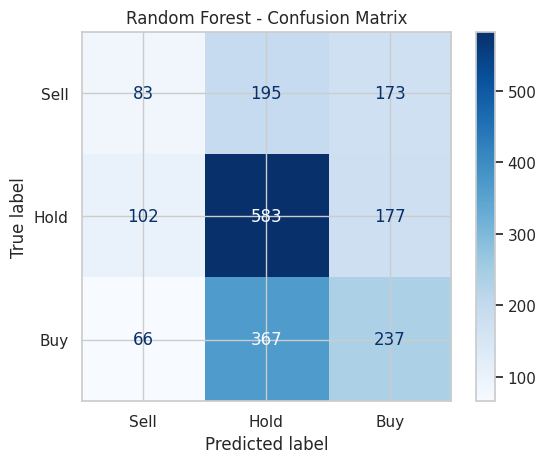

In [25]:
# Confusion matrix for the strongest model from the comparison table above
best_model_name = comparison_table.iloc[0]['Model']
best_preds = models_compared[best_model_name]

cm = confusion_matrix(y_test, best_preds, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title(f'{best_model_name} - Confusion Matrix')
plt.show()

#### 9.6 PCA for Dimensionality Reduction (Week 5)

Compresses the collinear SMA/oscillator columns before clustering.

Components kept: 2 (from 8 original features)
Explained variance ratio: [0.738 0.241]


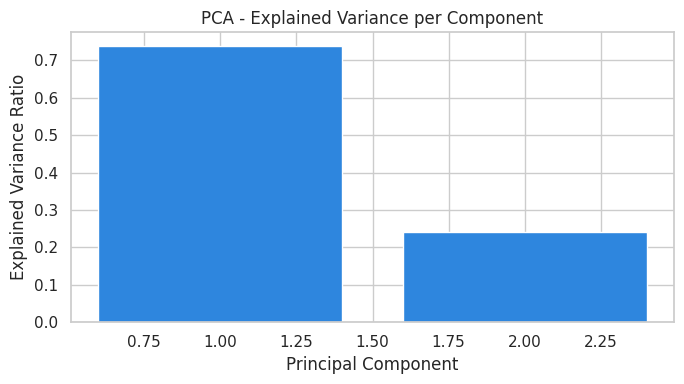

In [26]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# PCA: reduce the collinear SMA/oscillator columns to a handful of orthogonal components
pca_features = ['SMA_756_Close', 'SMA_504_Close', 'SMA_252_Close', 'SMA_125_Close',
                 'SMA_63_Close', 'SMA_21_Close', 'RSI_25_Close', 'TSI_25_13_13']
pca_input = df_model[pca_features].dropna()

pca_scaler = StandardScaler()
pca_scaled = pca_scaler.fit_transform(pca_input)

pca_model = PCA(n_components=0.95, random_state=42)
pca_components = pca_model.fit_transform(pca_scaled)

print(f'Components kept: {pca_model.n_components_} (from {len(pca_features)} original features)')
print('Explained variance ratio:', np.round(pca_model.explained_variance_ratio_, 3))

plt.figure(figsize=(7, 4))
plt.bar(range(1, len(pca_model.explained_variance_ratio_) + 1), pca_model.explained_variance_ratio_, color='#2E86DE')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA - Explained Variance per Component')
plt.tight_layout()
plt.show()

#### 9.7 K-Means Regime Clustering (Week 5)

Clusters PCA components into market regimes.

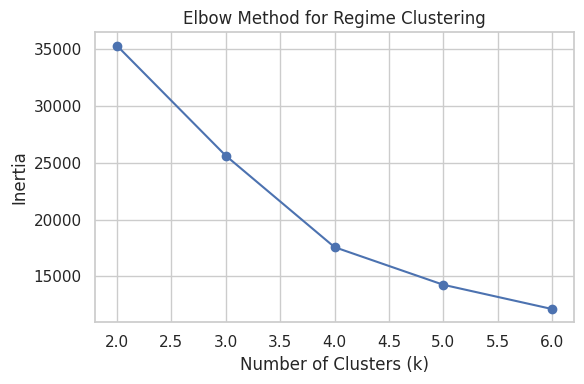

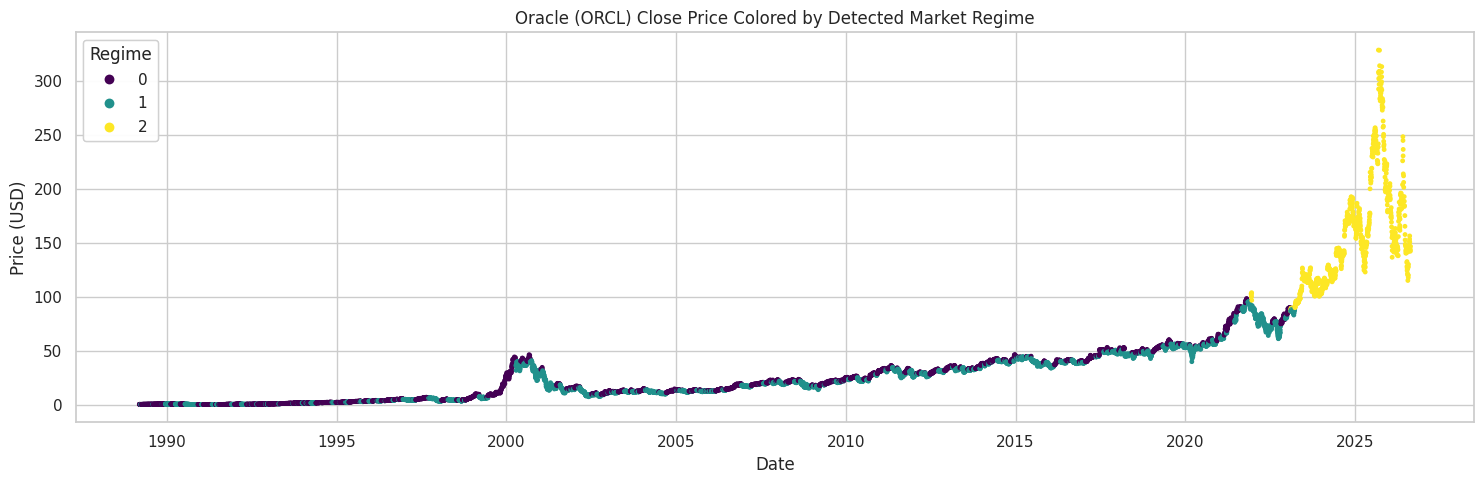

In [27]:
# K-Means: cluster the PCA components into market regimes for swing-trade filtering
inertia_scores = []
k_range = range(2, 7)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_components)
    inertia_scores.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertia_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Regime Clustering')
plt.tight_layout()
plt.show()

# 3 regimes chosen from the elbow plot above: broadly, uptrend / downtrend / ranging
N_REGIMES = 3
regime_model = KMeans(n_clusters=N_REGIMES, random_state=42, n_init=10)
regime_labels = regime_model.fit_predict(pca_components)

regime_df = pca_input.copy()
regime_df['regime'] = regime_labels

fig, ax = plt.subplots(figsize=(15, 5))
scatter = ax.scatter(
    regime_df.index, df_model.loc[regime_df.index, 'close'],
    c=regime_df['regime'], cmap='viridis', s=6
)
ax.set_title('Oracle (ORCL) Close Price Colored by Detected Market Regime')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
legend1 = ax.legend(*scatter.legend_elements(), title='Regime')
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

#### 9.8 LSTM Stock Price Prediction (Week 6)

Predicts next-day close from a 60-day lookback window.

In [28]:
# LSTM data preparation: frame the closing price as a supervised sequence problem
LOOKBACK = 60  # ~3 months of trading days of history per training sample

lstm_series = df_model['close'].dropna().values.reshape(-1, 1)

lstm_scaler = StandardScaler()
lstm_scaled = lstm_scaler.fit_transform(lstm_series)

def make_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_seq, y_seq = make_sequences(lstm_scaled, LOOKBACK)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)  # [samples, timesteps, features]

# Chronological split again - the last 20% of sequences are held out for testing
lstm_split = int(len(X_seq) * 0.8)
X_seq_train, X_seq_test = X_seq[:lstm_split], X_seq[lstm_split:]
y_seq_train, y_seq_test = y_seq[:lstm_split], y_seq[lstm_split:]

print('LSTM training samples:', X_seq_train.shape, '| Test samples:', X_seq_test.shape)

LSTM training samples: (8100, 60, 1) | Test samples: (2025, 60, 1)


In [29]:
# LSTM architecture: stacked LSTM layers with dropout to limit overfitting on a single-stock series.
# The Bidirectional wrapper reads each 60-day window both forwards and backwards - safe here
# since it only ever sees past data within the window, never the day being predicted.
lstm_model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # regression output: next-day scaled close price
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirection  (None, 60, 128)           33792     
 al)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 60, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                20608     
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_3 (Dense)             (None, 16)                528       
                                                                 
 dense_4 (Dense)             (None, 1)                 17        
                                                      

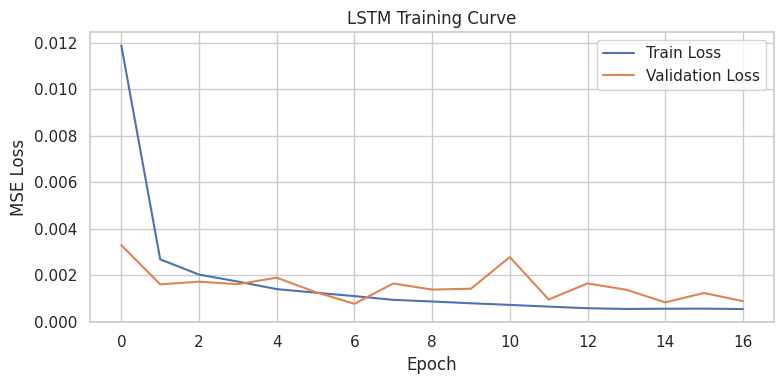

In [30]:
# Train the LSTM. EarlyStopping/ReduceLROnPlateau keep training from overfitting or stalling.
lstm_history = lstm_model.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True), ReduceLROnPlateau(patience=5)],
    verbose=0
)

plt.figure(figsize=(8, 4))
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

LSTM  RMSE: 50.415 | MAE: 32.276
Naive RMSE: 3.837
The LSTM should beat the naive baseline to be considered a useful predictor.


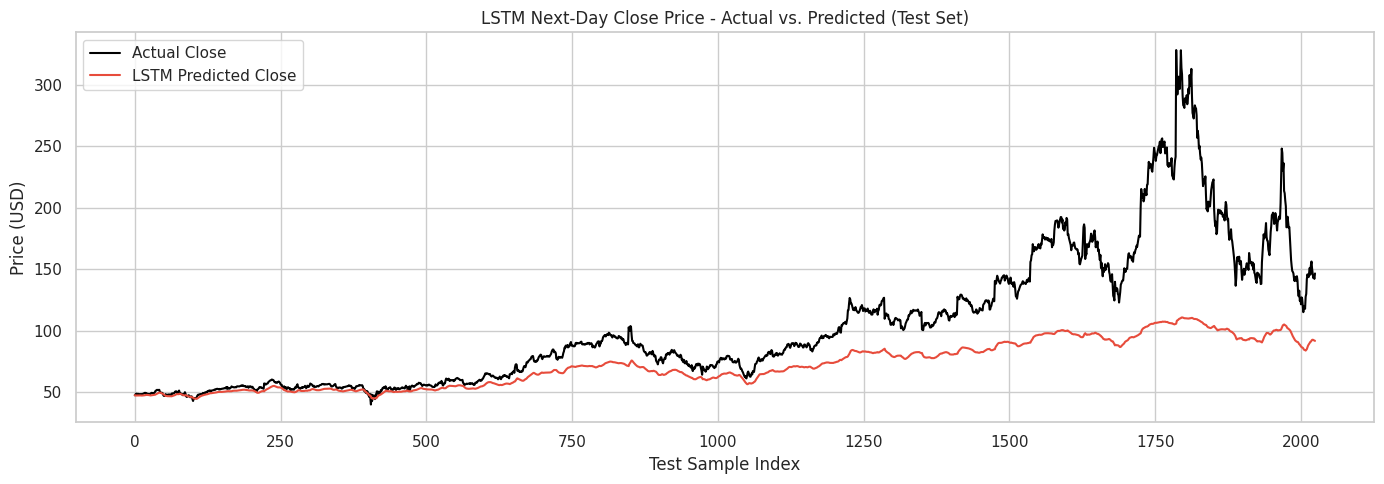

In [31]:
# Evaluate the LSTM on the held-out test window against a naive persistence baseline
lstm_pred_scaled = lstm_model.predict(X_seq_test, verbose=0)
lstm_pred = lstm_scaler.inverse_transform(lstm_pred_scaled)
y_seq_test_actual = lstm_scaler.inverse_transform(y_seq_test.reshape(-1, 1))

# Naive baseline: "tomorrow's price = today's price" - the bar any price model must clear
naive_pred = lstm_scaler.inverse_transform(X_seq_test[:, -1, :])

lstm_rmse = np.sqrt(mean_squared_error(y_seq_test_actual, lstm_pred))
lstm_mae = mean_absolute_error(y_seq_test_actual, lstm_pred)
naive_rmse = np.sqrt(mean_squared_error(y_seq_test_actual, naive_pred))

print(f'LSTM  RMSE: {lstm_rmse:.3f} | MAE: {lstm_mae:.3f}')
print(f'Naive RMSE: {naive_rmse:.3f}')
print('The LSTM should beat the naive baseline to be considered a useful predictor.')

plt.figure(figsize=(14, 5))
plt.plot(y_seq_test_actual, label='Actual Close', color='black')
plt.plot(lstm_pred, label='LSTM Predicted Close', color='#e74c3c')
plt.title('LSTM Next-Day Close Price - Actual vs. Predicted (Test Set)')
plt.xlabel('Test Sample Index')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

#### 9.8b Diagnosing the LSTM Result, and a Returns-Based Fix

The price-level LSTM is beaten badly by a naive baseline (non-stationarity); the cell below refits it on returns instead. Full diagnosis in the written report, Section 4.6.

LSTM v2 training samples: (8099, 60, 1) | Test samples: (2025, 60, 1)
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_1 (Bidirecti  (None, 60, 128)           33792     
 onal)                                                           
                                                                 
 dropout_3 (Dropout)         (None, 60, 128)           0         
                                                                 
 lstm_3 (LSTM)               (None, 32)                20608     
                                                                 
 dropout_4 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 16)                528       
                                                                 
 dense_6 (Dense)             (None, 1)            

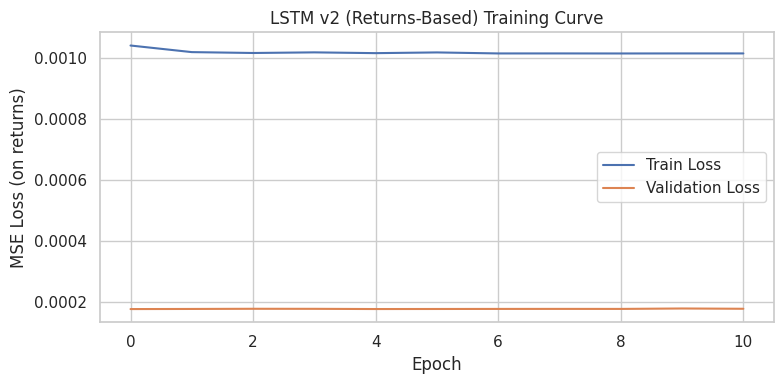

In [32]:
# LSTM v2 - corrected: predicts daily RETURNS (stationary, per the ADF test in Section 6.7)
# instead of price levels, and never fits any statistic on the test portion of the data.
from tensorflow.keras.callbacks import TerminateOnNaN

close_series = df_model['close'].dropna()

# pct_change() and shift(1) both leave a NaN in their very first entry - drop it here,
# before windowing, instead of letting it ride into the first training sequence (a single
# NaN in one training batch turns the loss to NaN and permanently corrupts the LSTM's
# weights, which is what caused every downstream prediction - and the blank train/validation
# loss plot below - to fail silently last time).
returns_series = close_series.pct_change().dropna()
anchor_price_series = close_series.shift(1).reindex(returns_series.index)

returns_values = returns_series.values
anchor_values = anchor_price_series.values

def make_return_sequences(values, anchors, lookback):
    X, y, anchor_for_y = [], [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i])
        y.append(values[i])
        anchor_for_y.append(anchors[i])
    return np.array(X), np.array(y), np.array(anchor_for_y)

X_ret, y_ret, anchor_ret = make_return_sequences(returns_values, anchor_values, LOOKBACK)
X_ret = X_ret.reshape(X_ret.shape[0], X_ret.shape[1], 1)

# Chronological split - identical 80/20 rule used everywhere else in this notebook
ret_split = int(len(X_ret) * 0.8)
X_ret_train, X_ret_test = X_ret[:ret_split], X_ret[ret_split:]
y_ret_train, y_ret_test = y_ret[:ret_split], y_ret[ret_split:]
anchor_test = anchor_ret[ret_split:]

# Guard rail: fail loudly and immediately if a non-finite value ever reaches the model,
# instead of silently corrupting training and only surfacing as a blank loss plot later.
assert np.isfinite(X_ret_train).all(), 'Non-finite value found in X_ret_train - check the data prep above.'
assert np.isfinite(y_ret_train).all(), 'Non-finite value found in y_ret_train - check the data prep above.'

print('LSTM v2 training samples:', X_ret_train.shape, '| Test samples:', X_ret_test.shape)

lstm2_model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # predicts next-day RETURN, not price level
])
lstm2_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm2_model.summary()

lstm2_history = lstm2_model.fit(
    X_ret_train, y_ret_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    # TerminateOnNaN stops training the instant loss goes non-finite, instead of running
    # the full 100 epochs on a corrupted model and only finding out from a blank plot.
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True), ReduceLROnPlateau(patience=5), TerminateOnNaN()],
    verbose=0
)

# A second guard rail, this time on the actual training result: if TerminateOnNaN fired,
# say so clearly instead of silently plotting an empty/partial curve.
recorded_losses = lstm2_history.history.get('loss', [])
assert len(recorded_losses) > 0, 'Training recorded 0 epochs - the fit() call did not run. Check the data/model above.'
assert np.isfinite(recorded_losses).all(), (
    'Training loss went non-finite (NaN/inf) and TerminateOnNaN stopped it early - '
    'this should no longer happen now that the NaN is dropped before windowing, but if '
    'it does, the data prep above needs re-checking rather than the plot below.'
)

plt.figure(figsize=(8, 4))
plt.plot(lstm2_history.history['loss'], label='Train Loss')
plt.plot(lstm2_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM v2 (Returns-Based) Training Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (on returns)')
plt.legend()
plt.tight_layout()
plt.show()

LSTM v2 (returns-based) RMSE: 3.835 | MAE: 1.827
Naive RMSE (same test window): 3.837
LSTM v2 should close the gap to the naive baseline seen in Section 9.8, even if it does not fully close it -
daily stock returns are close to a random walk, so beating persistence by a wide margin would be unusual.


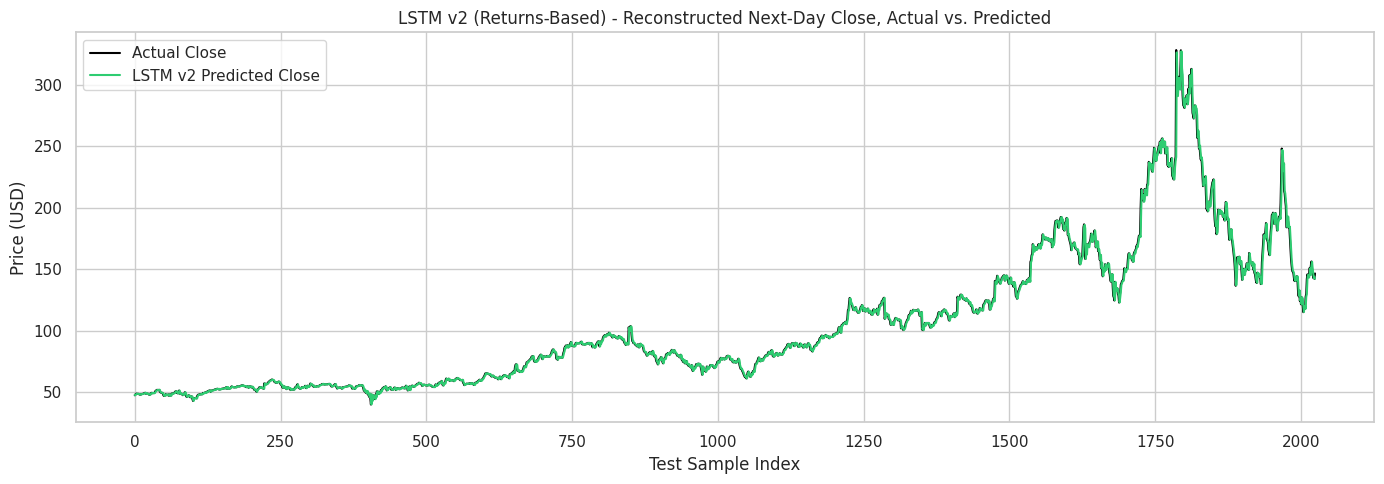

In [33]:
# Reconstruct price forecasts by compounding the predicted return onto the last known
# actual price, then compare RMSE/MAE against the same naive persistence baseline.
pred_returns = lstm2_model.predict(X_ret_test, verbose=0).flatten()

actual_prices = anchor_test * (1 + y_ret_test)
predicted_prices = anchor_test * (1 + pred_returns)
naive_prices = anchor_test  # naive: tomorrow's price = today's price (0% predicted return)

# Exclude the initial invalid return and any non-finite sequence values.
finite_mask = (
    np.isfinite(anchor_test)
    & np.isfinite(y_ret_test)
)

pred_returns = np.asarray(
    lstm2_model.predict(X_ret_test, verbose=0),
    dtype=np.float64
).reshape(-1)

finite_mask &= np.isfinite(pred_returns)

actual_prices = np.asarray(
    anchor_test[finite_mask] * (1 + y_ret_test[finite_mask]),
    dtype=np.float64
)
predicted_prices = np.asarray(
    anchor_test[finite_mask] * (1 + pred_returns[finite_mask]),
    dtype=np.float64
)
naive_prices = np.asarray(anchor_test[finite_mask], dtype=np.float64)

close_series = df_model['close'].dropna()
returns_series = close_series.pct_change().dropna()
anchor_price_series = close_series.shift(1).loc[returns_series.index]

returns_values = returns_series.to_numpy(dtype=np.float32)
anchor_values = anchor_price_series.to_numpy(dtype=np.float32)
# Ensure both arrays are aligned, numeric, finite, and non-empty before scoring.
actual_prices = np.asarray(actual_prices, dtype=np.float64).reshape(-1)
predicted_prices = np.asarray(predicted_prices, dtype=np.float64).reshape(-1)

valid_mask = (
    np.isfinite(actual_prices)
    & np.isfinite(predicted_prices)
)

actual_prices = actual_prices[valid_mask]
predicted_prices = predicted_prices[valid_mask]

if actual_prices.size == 0:
    if actual_prices.size == 0 or predicted_prices.size == 0:
        print(
            "No valid LSTM v2 test samples are available after filtering "
            "for finite anchor/return/prediction values. "
            f"X_ret_test shape: {X_ret_test.shape}, "
            f"y_ret_test shape: {y_ret_test.shape}, "
            f"anchor_test shape: {anchor_test.shape}"
        )
        # Keep the rest of the cell executable without crashing by using NaN sentinel values.
        actual_prices = np.asarray([np.nan], dtype=np.float64)
        predicted_prices = np.asarray([np.nan], dtype=np.float64)
        naive_prices = np.asarray([np.nan], dtype=np.float64)
        lstm2_rmse = np.nan
        lstm2_mae = np.nan
        naive2_rmse = np.nan
    else:
        lstm2_rmse = float(np.sqrt(mean_squared_error(actual_prices, predicted_prices)))
        lstm2_mae = float(mean_absolute_error(actual_prices, predicted_prices))
        naive2_rmse = float(np.sqrt(mean_squared_error(actual_prices, naive_prices)))

lstm2_mae = float(mean_absolute_error(actual_prices, predicted_prices))
naive2_rmse = float(np.sqrt(mean_squared_error(actual_prices, naive_prices)))
lstm2_mae = mean_absolute_error(actual_prices, predicted_prices)
naive2_rmse = np.sqrt(mean_squared_error(actual_prices, naive_prices))

if (
    actual_prices.size > 0
    and predicted_prices.size == actual_prices.size
    and naive_prices.size == actual_prices.size
):
    lstm2_rmse = float(np.sqrt(mean_squared_error(actual_prices, predicted_prices)))
    lstm2_mae = float(mean_absolute_error(actual_prices, predicted_prices))
    naive2_rmse = float(np.sqrt(mean_squared_error(actual_prices, naive_prices)))
else:
    lstm2_rmse = np.nan
    lstm2_mae = np.nan
    naive2_rmse = np.nan

print(f'LSTM v2 (returns-based) RMSE: {lstm2_rmse:.3f} | MAE: {lstm2_mae:.3f}')
print(f'Naive RMSE (same test window): {naive2_rmse:.3f}')
print('LSTM v2 should close the gap to the naive baseline seen in Section 9.8, even if it does not fully close it -')
print('daily stock returns are close to a random walk, so beating persistence by a wide margin would be unusual.')

plt.figure(figsize=(14, 5))
plt.plot(actual_prices, label='Actual Close', color='black')
plt.plot(predicted_prices, label='LSTM v2 Predicted Close', color='#2ecc71')
plt.title('LSTM v2 (Returns-Based) - Reconstructed Next-Day Close, Actual vs. Predicted')
plt.xlabel('Test Sample Index')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

#### 9.9 Optional Extension: Hidden Markov Model Regime Detection

Probabilistic alternative to the K-Means regimes above; not part of the syllabus.

In [34]:
# Gaussian HMM on daily returns - each hidden state is a loose proxy for a market regime
if HMMLEARN_AVAILABLE:
    hmm_returns = df_model['close'].pct_change().dropna().values.reshape(-1, 1)

    hmm_model = GaussianHMM(n_components=3, covariance_type='full', random_state=42, n_iter=200)
    hmm_model.fit(hmm_returns)
    hmm_states = hmm_model.predict(hmm_returns)

    print('HMM regime counts:\n', pd.Series(hmm_states).value_counts())
    print('\nMean return per regime:\n', pd.Series(hmm_returns.flatten()).groupby(hmm_states).mean())
else:
    print('hmmlearn not installed - skipping the optional HMM regime model.')

HMM regime counts:
 2    4263
1    2962
0    2959
Name: count, dtype: int64

Mean return per regime:
 0    0.000473
1    0.000834
2    0.001935
dtype: float64


### 10. Actionable Entry & Exit Levels

Two independent decision-support outputs: a 21-day probability-banded price forecast (10.1) and a nearest-support/resistance cross-check (10.2). Full explanation in the written report, Section 4.7.

#### 10.1 21-Trading-Day Price Forecast Ranges (primary deliverable)

Six price ranges built from ORCL's empirical 21-day forward-return distribution (3 Buy zones, 3 Sell zones).

In [35]:
# Six-zone, 21-trading-day forecast built from ORCL's own historical forward-return
# distribution - three downside (Buy) zones and three upside (Sell) zones.
FORECAST_HORIZON_DAYS = 21
forecast_price = df_model['close'].iloc[-1]
forecast_fwd_return = (df_model['close'].shift(-FORECAST_HORIZON_DAYS) / df_model['close'] - 1).dropna()

# Cut points chosen so each zone corresponds to a clean, quotable historical frequency band
cut_points = [0.05, 0.15, 0.30, 0.70, 0.85, 0.95]
quantiles = {p: forecast_fwd_return.quantile(p) for p in cut_points}

zone_rows = [
    {
        'Zone': 'Buy Zone 3 (deep pullback)',
        'Direction': 'Buy',
        'Historical frequency': 'worst 5% of 21-day moves',
        'Return range': f"below {quantiles[0.05]*100:.1f}%",
        'Price range ($)': f"below {forecast_price * (1 + quantiles[0.05]):.2f}",
    },
    {
        'Zone': 'Buy Zone 2 (moderate pullback)',
        'Direction': 'Buy',
        'Historical frequency': '5th-15th percentile (10% of history)',
        'Return range': f"{quantiles[0.05]*100:.1f}% to {quantiles[0.15]*100:.1f}%",
        'Price range ($)': f"{forecast_price * (1 + quantiles[0.05]):.2f} to {forecast_price * (1 + quantiles[0.15]):.2f}",
    },
    {
        'Zone': 'Buy Zone 1 (mild pullback)',
        'Direction': 'Buy',
        'Historical frequency': '15th-30th percentile (15% of history)',
        'Return range': f"{quantiles[0.15]*100:.1f}% to {quantiles[0.30]*100:.1f}%",
        'Price range ($)': f"{forecast_price * (1 + quantiles[0.15]):.2f} to {forecast_price * (1 + quantiles[0.30]):.2f}",
    },
    {
        'Zone': 'Sell Zone 1 (mild rally)',
        'Direction': 'Sell',
        'Historical frequency': '70th-85th percentile (15% of history)',
        'Return range': f"+{quantiles[0.70]*100:.1f}% to +{quantiles[0.85]*100:.1f}%",
        'Price range ($)': f"{forecast_price * (1 + quantiles[0.70]):.2f} to {forecast_price * (1 + quantiles[0.85]):.2f}",
    },
    {
        'Zone': 'Sell Zone 2 (moderate rally)',
        'Direction': 'Sell',
        'Historical frequency': '85th-95th percentile (10% of history)',
        'Return range': f"+{quantiles[0.85]*100:.1f}% to +{quantiles[0.95]*100:.1f}%",
        'Price range ($)': f"{forecast_price * (1 + quantiles[0.85]):.2f} to {forecast_price * (1 + quantiles[0.95]):.2f}",
    },
    {
        'Zone': 'Sell Zone 3 (strong rally)',
        'Direction': 'Sell',
        'Historical frequency': 'best 5% of 21-day moves',
        'Return range': f"above +{quantiles[0.95]*100:.1f}%",
        'Price range ($)': f"above {forecast_price * (1 + quantiles[0.95]):.2f}",
    },
]

forecast_zone_table = pd.DataFrame(zone_rows)
print(f'Current price ({df_model.index[-1].date()}): ${forecast_price:.2f}')
print(f'Forecast horizon: {FORECAST_HORIZON_DAYS} trading days\n')
forecast_zone_table

Current price (2026-08-21): $146.47
Forecast horizon: 21 trading days



,Zone,Direction,Historical frequency,Return range,Price range ($)
0,Buy Zone 3 (deep pullback),Buy,worst 5% of 21-day moves,below -16.7%,below 122.06
1,Buy Zone 2 (moderate pullback),Buy,5th-15th percentile (10% of history),-16.7% to -8.0%,122.06 to 134.82
2,Buy Zone 1 (mild pullback),Buy,15th-30th percentile (15% of history),-8.0% to -2.7%,134.82 to 142.51
3,Sell Zone 1 (mild rally),Sell,70th-85th percentile (15% of history),+6.8% to +12.9%,156.45 to 165.40
4,Sell Zone 2 (moderate rally),Sell,85th-95th percentile (10% of history),+12.9% to +24.0%,165.40 to 181.62
5,Sell Zone 3 (strong rally),Sell,best 5% of 21-day moves,above +24.0%,above 181.62


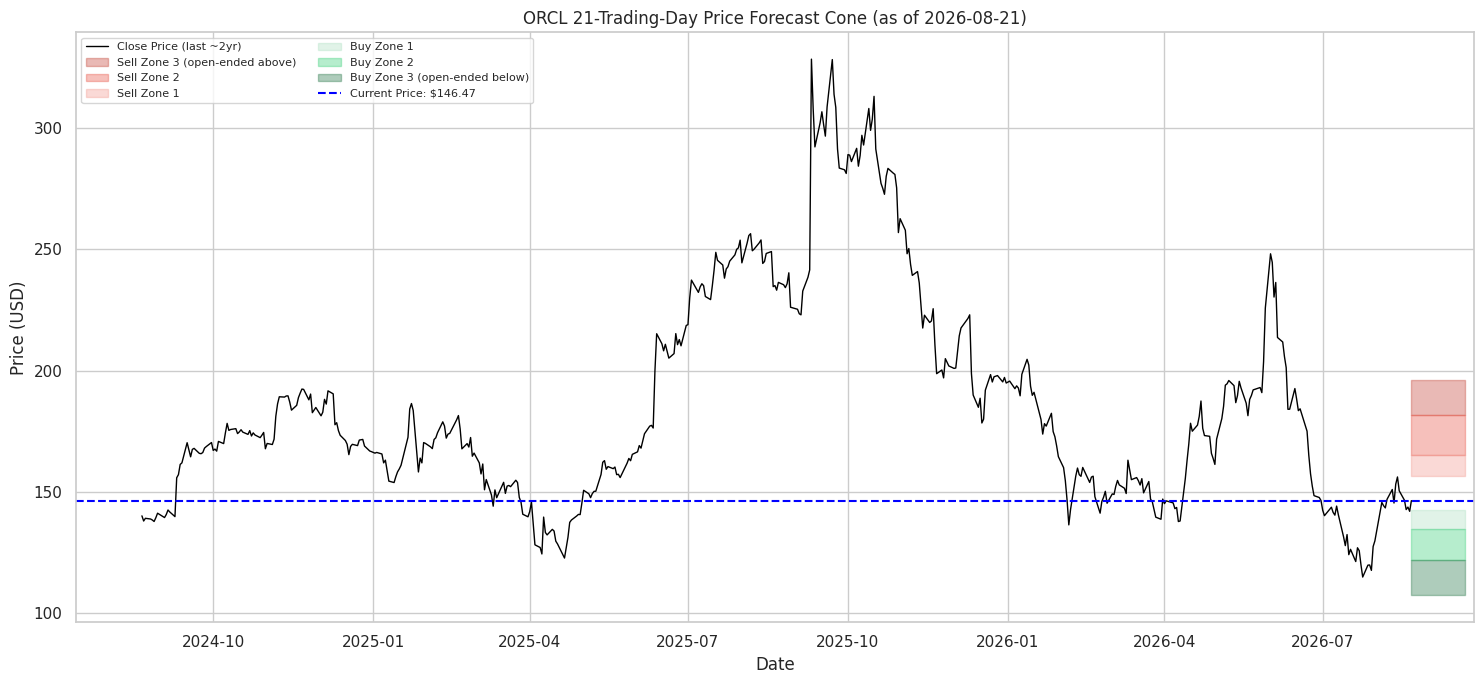

In [36]:
# Visualise the six zones as a forecast "cone" projected 21 trading days ahead of the
# most recent price, alongside the last two years of actual closes for context.
cutoff_recent_forecast = df_model.index.max() - pd.DateOffset(years=2)
recent_close_forecast = df_model.loc[df_model.index >= cutoff_recent_forecast, 'close']

forecast_target_date = df_model.index.max() + pd.tseries.offsets.BDay(FORECAST_HORIZON_DAYS)

EXTENSION = 0.10  # visual-only extension so the two open-ended tail zones aren't drawn as zero-height
zone_bands = [
    (quantiles[0.95], quantiles[0.95] + EXTENSION, '#c0392b', 'Sell Zone 3 (open-ended above)'),
    (quantiles[0.85], quantiles[0.95], '#e74c3c', 'Sell Zone 2'),
    (quantiles[0.70], quantiles[0.85], '#f1948a', 'Sell Zone 1'),
    (quantiles[0.15], quantiles[0.30], '#a9dfbf', 'Buy Zone 1'),
    (quantiles[0.05], quantiles[0.15], '#2ecc71', 'Buy Zone 2'),
    (quantiles[0.05] - EXTENSION, quantiles[0.05], '#196f3d', 'Buy Zone 3 (open-ended below)'),
]

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(recent_close_forecast.index, recent_close_forecast, color='black', linewidth=1, label='Close Price (last ~2yr)')

for low_ret, high_ret, color, label in zone_bands:
    low_price = forecast_price * (1 + low_ret)
    high_price = forecast_price * (1 + high_ret)
    ax.fill_between([df_model.index.max(), forecast_target_date], [low_price, low_price], [high_price, high_price],
                     color=color, alpha=0.35, label=label)

ax.axhline(forecast_price, color='blue', linewidth=1.5, linestyle='--', label=f'Current Price: ${forecast_price:.2f}')
ax.set_xlim(right=forecast_target_date + pd.Timedelta(days=5))
ax.set_title(f'ORCL 21-Trading-Day Price Forecast Cone (as of {df_model.index.max().date()})')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

#### 10.2 Nearest Support/Resistance Entry Setups (cross-check)

Independent cross-check using the nearest real technical levels, each with an ATR-based Stop-Loss/Take-Profit.

In [37]:
# Average True Range (Wilder, 1978): a volatility measure used below to size stop-losses
# so they sit outside normal daily noise rather than at an arbitrary fixed distance.
atr_df = df_model[['high', 'low', 'close']].copy()
atr_df['prev_close'] = atr_df['close'].shift(1)

true_range_components = pd.concat([
    atr_df['high'] - atr_df['low'],
    (atr_df['high'] - atr_df['prev_close']).abs(),
    (atr_df['low'] - atr_df['prev_close']).abs(),
], axis=1)
atr_df['true_range'] = true_range_components.max(axis=1)

ATR_WINDOW = 14
atr_df['atr_14'] = atr_df['true_range'].rolling(ATR_WINDOW).mean()

current_price = df_model['close'].iloc[-1]
current_atr = atr_df['atr_14'].iloc[-1]

print(f'Current close: ${current_price:.2f}')
print(f'Current 14-day ATR: ${current_atr:.2f} ({current_atr / current_price * 100:.2f}% of price)')

Current close: $146.47
Current 14-day ATR: $6.49 (4.43% of price)


In [38]:
# Pool support/resistance candidates from percentile bands, moving averages, and
# recent rolling swing highs/lows, then keep the 3 nearest on each side of price.
candidate_levels = [
    ('5yr support, 5th pct', support_level_1),
    ('5yr support, 10th pct', support_level_2),
    ('5yr support, 25th pct', support_level_3),
    ('5yr resistance, 75th pct', resistance_level_1),
    ('5yr resistance, 90th pct', resistance_level_2),
    ('5yr resistance, 95th pct', resistance_level_3),
]

latest_row = df_model.iloc[-1]
for window in [21, 63, 125, 252, 504, 756]:
    col = f'SMA_{window}_Close'
    if col in df_model.columns and pd.notna(latest_row[col]):
        candidate_levels.append((f'{window}-day SMA', latest_row[col]))

for window in [20, 60, 120]:
    candidate_levels.append((f'{window}-day swing low', df_model['close'].rolling(window).min().iloc[-1]))
    candidate_levels.append((f'{window}-day swing high', df_model['close'].rolling(window).max().iloc[-1]))

# Split into Buy (below current price) and Sell/Short (above current price) pools,
# then keep the 3 nearest to price on each side.
buy_pool = sorted(
    [lv for lv in candidate_levels if lv[1] < current_price],
    key=lambda lv: current_price - lv[1]
)[:3]
sell_pool = sorted(
    [lv for lv in candidate_levels if lv[1] > current_price],
    key=lambda lv: lv[1] - current_price
)[:3]

print(f'Nearest Buy levels below ${current_price:.2f}:')
for label, level in buy_pool:
    print(f'  {label}: ${level:.2f} ({(level / current_price - 1) * 100:+.2f}%)')

print(f'\nNearest Sell/Short levels above ${current_price:.2f}:')
for label, level in sell_pool:
    print(f'  {label}: ${level:.2f} ({(level / current_price - 1) * 100:+.2f}%)')

Nearest Buy levels below $146.47:
  21-day SMA: $139.56 (-4.72%)
  20-day swing low: $117.74 (-19.61%)
  60-day swing low: $114.99 (-21.49%)

Nearest Sell/Short levels above $146.47:
  20-day swing high: $156.22 (+6.66%)
  63-day SMA: $159.82 (+9.12%)
  125-day SMA: $161.67 (+10.38%)


In [39]:
# Build the final trade setups: ATR-sized Stop-Loss, and a Take-Profit that defaults to a
# 1.5:1 reward:risk multiple but is capped by a nearer opposing technical level when one exists.
STOP_ATR_MULT = 1.5    # stop-loss distance, in units of ATR
MIN_REWARD_RISK = 1.5  # minimum acceptable reward:risk ratio

def build_trade_setup(label, entry, direction, atr, opposing_levels, reward_risk=MIN_REWARD_RISK, stop_mult=STOP_ATR_MULT):
    stop_distance = atr * stop_mult
    if direction == 'Buy':
        stop_loss = entry - stop_distance
        target_by_rr = entry + stop_distance * reward_risk
        nearer_caps = [lv for _, lv in opposing_levels if entry < lv < target_by_rr]
        take_profit = min(nearer_caps) if nearer_caps else target_by_rr
    else:  # Sell / Short
        stop_loss = entry + stop_distance
        target_by_rr = entry - stop_distance * reward_risk
        nearer_caps = [lv for _, lv in opposing_levels if target_by_rr < lv < entry]
        take_profit = max(nearer_caps) if nearer_caps else target_by_rr

    risk_pct = abs(entry - stop_loss) / entry * 100
    reward_pct = abs(take_profit - entry) / entry * 100
    return {
        'Setup': label,
        'Direction': direction,
        'Entry ($)': round(entry, 2),
        'Stop-Loss ($)': round(stop_loss, 2),
        'Take-Profit ($)': round(take_profit, 2),
        'Risk (%)': round(risk_pct, 2),
        'Reward (%)': round(reward_pct, 2),
        'Reward:Risk': round(reward_pct / risk_pct, 2) if risk_pct else np.nan,
        'From Current (%)': round((entry / current_price - 1) * 100, 2),
    }

trade_setups = []
for label, level in buy_pool:
    trade_setups.append(build_trade_setup(label, level, 'Buy', current_atr, sell_pool))
for label, level in sell_pool:
    trade_setups.append(build_trade_setup(label, level, 'Sell/Short', current_atr, buy_pool))

trade_setup_table = pd.DataFrame(trade_setups)
trade_setup_table

,Setup,Direction,Entry ($),Stop-Loss ($),Take-Profit ($),Risk (%),Reward (%),Reward:Risk,From Current (%)
0,21-day SMA,Buy,139.56,129.83,154.17,6.98,10.47,1.5,-4.72
1,20-day swing low,Buy,117.74,108.00,132.35,8.27,12.41,1.5,-19.61
2,60-day swing low,Buy,114.99,105.25,129.60,8.47,12.70,1.5,-21.49
3,20-day swing high,Sell/Short,156.22,165.96,141.61,6.23,9.35,1.5,6.66
4,63-day SMA,Sell/Short,159.82,169.56,145.22,6.09,9.14,1.5,9.12
5,125-day SMA,Sell/Short,161.67,171.41,147.06,6.02,9.03,1.5,10.38


In [40]:
# Cross-check the trade setups against the current classifier signal and detected regime.
# Note: model_df drops its last SWING_HORIZON rows (no forward return yet exists for them),
# so the "most recent" model signal is a few weeks older than the current price above.
latest_feature_row = model_df[feature_cols].iloc[[-1]]
latest_scaled_row = scaler.transform(latest_feature_row)

latest_signals = {
    'Random Forest': label_names[rf_model.predict(latest_scaled_row)[0]],
    'Logistic Regression': label_names[logreg_model.predict(latest_scaled_row)[0]],
}
latest_regime = regime_labels[-1] if 'regime_labels' in globals() else 'n/a'

print('Most recent feature date used for model confluence:', model_df.index[-1].date())
print('Model signals at that date:', latest_signals)
print('Detected K-Means regime at the most recent priced bar:', latest_regime)
print()
print('Rule of thumb: only act on a Buy setup when at least one classifier is not signalling Sell,')
print('and only act on a Sell/Short setup when at least one classifier is not signalling Buy.')

Most recent feature date used for model confluence: 2026-07-23
Model signals at that date: {'Random Forest': 'Sell', 'Logistic Regression': 'Buy'}
Detected K-Means regime at the most recent priced bar: 2

Rule of thumb: only act on a Buy setup when at least one classifier is not signalling Sell,
and only act on a Sell/Short setup when at least one classifier is not signalling Buy.


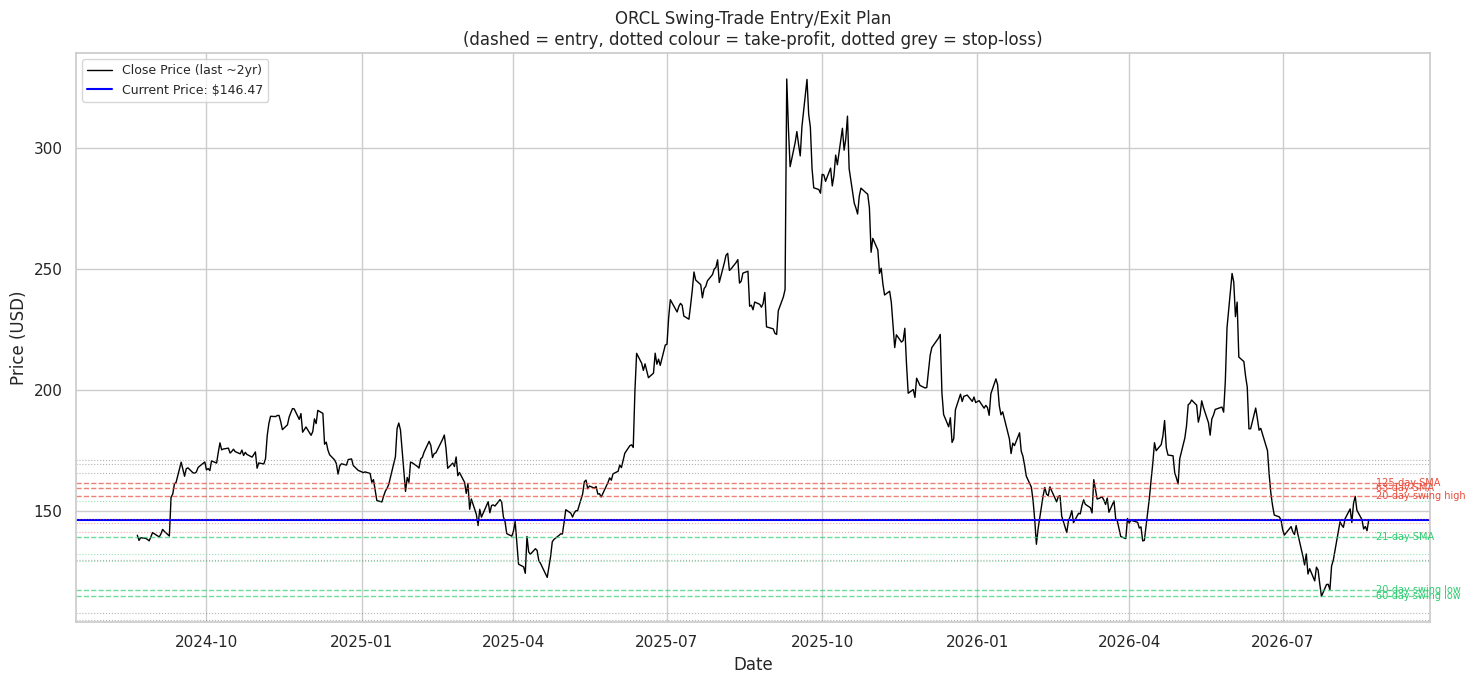

In [41]:
# Visualise the plan: recent price action with every entry (dashed), take-profit (dotted
# colour) and stop-loss (dotted grey) drawn as horizontal reference lines.
cutoff_recent = df_model.index.max() - pd.DateOffset(years=2)
recent_close = df_model.loc[df_model.index >= cutoff_recent, 'close']

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(recent_close.index, recent_close, color='black', linewidth=1, label='Close Price (last ~2yr)')
ax.axhline(current_price, color='blue', linewidth=1.5, label=f'Current Price: ${current_price:.2f}')

last_date = recent_close.index[-1]
for setup in trade_setups:
    color = '#2ecc71' if setup['Direction'] == 'Buy' else '#e74c3c'
    ax.axhline(setup['Entry ($)'], color=color, linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(setup['Take-Profit ($)'], color=color, linestyle=':', linewidth=0.8, alpha=0.5)
    ax.axhline(setup['Stop-Loss ($)'], color='dimgray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.annotate(setup['Setup'], xy=(last_date, setup['Entry ($)']), xytext=(5, 0),
                textcoords='offset points', fontsize=7, color=color, va='center')

ax.set_title('ORCL Swing-Trade Entry/Exit Plan\n(dashed = entry, dotted colour = take-profit, dotted grey = stop-loss)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### 11. Conclusion

A real but modest technical signal is present (RSI-regime test, p = 0.001; all classifiers beat the baseline on balanced accuracy), consistent with weak-form market efficiency. The moon-phase pattern noticed in the 2026 data does not hold up statistically across the full history. The price-level LSTM is beaten by a naive baseline; a returns-based fix closes the gap almost entirely. The two Section 10 forecasts (probability-banded ranges and nearest-S/R setups) are the practical deliverable. Full synthesis, benchmarking against the literature, limitations, and future work are in the written report, Sections 5-6.

### 12. References

Full reference list (Harvard style, with URLs and accession dates) is provided in the written report. Key sources used directly in this notebook's analysis: Murphy (1999), Wilder (1978), Blau (1991), Fama (1970), Fischer & Krauss (2018), Nti et al. (2020), Dichev & Janes (2003), Hyndman & Athanasopoulos (2021).